# Modelos de Machine Learning (Bucaramanga)
## Solución Inteligente de Seguridad Ciudadana para Santander (Bucaramanga)

**Objetivo:** Implementar un sistema híbrido de predicción de criminalidad que integra tres módulos complementarios:

1. **Módulo Temporal**: Predicción de tendencias y patrones temporales
2. **Módulo Espacial**: Identificación de hotspots y análisis geográfico
3. **Módulo de Riesgo**: Clasificación y scoring de riesgo por zona-tiempo

**Arquitectura del Sistema:**
```
┌─────────────────────────────────────────────────────────┐
│          SISTEMA INTEGRADO DE PREDICCIÓN                │
└─────────────────────────────────────────────────────────┘
                          │
          ┌───────────────┼───────────────┐
          │               │               │
          ▼               ▼               ▼
    ┌─────────┐    ┌──────────┐    ┌─────────┐
    │ Módulo  │    │  Módulo  │    │ Módulo  │
    │Temporal │    │ Espacial │    │  Riesgo │
    └─────────┘    └──────────┘    └─────────┘
    SARIMA +       DBSCAN +         XGBoost
    Prophet        KDE              Classifier
         │              │                │
         └──────────────┼────────────────┘
                        ▼
              ┌──────────────────┐
              │ ENSEMBLE FINAL   │
              │ (Integración)    │
              └──────────────────┘
```

**Fecha de desarrollo:** Noviembre 26, 2025
**Datasets base:** Resultados del EDA (eda.ipynb)

## 📋 Tabla de Contenido

### FASE 1: Preparación de Datos
1. [Configuración Inicial](#1-configuracion)
2. [Carga y Preprocesamiento de Datos](#2-carga-datos)
3. [Ingeniería de Features](#3-feature-engineering)

### FASE 2: Módulo Temporal
4. [Preparación de Series Temporales](#4-prep-temporal)
5. [Modelo SARIMA](#5-sarima)
6. [Modelo Prophet](#6-prophet)

### FASE 3: Módulo Espacial
7. [Preparación de Datos Geográficos](#7-prep-espacial)
8. [Clustering con DBSCAN](#8-dbscan)
9. [Mapas de Calor con KDE](#9-kde)

### FASE 4: Módulo de Riesgo
10. [Preparación de Features para Clasificación](#10-prep-riesgo)
11. [Modelo XGBoost](#11-xgboost)

### FASE 5: Integración y Deployment
12. [Sistema Ensemble](#12-ensemble)
13. [Exportación de Modelos](#13-export)

---

# FASE 1: PREPARACIÓN DE DATOS

---

## 1. Configuración Inicial e Importación de Librerías <a id='1-configuracion'></a>

In [1]:
# ============================================================================
# LIBRERÍAS GENERALES
# ============================================================================
import pandas as pd
import numpy as np
import warnings
import os
import pickle
import json
from datetime import datetime, timedelta
from dotenv import load_dotenv
from pathlib import Path

# ============================================================================
# VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================================
# MODELOS DE SERIES TEMPORALES
# ============================================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# ============================================================================
# MODELOS DE CLUSTERING Y ANÁLISIS ESPACIAL
# ============================================================================
from sklearn.cluster import DBSCAN, KMeans
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist

# ============================================================================
# MODELOS DE CLASIFICACIÓN Y REGRESIÓN
# ============================================================================
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ============================================================================
# PREPROCESAMIENTO Y FEATURE ENGINEERING
# ============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ============================================================================
# MÉTRICAS DE EVALUACIÓN
# ============================================================================
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
)

# ============================================================================
# MANEJO DE DESBALANCEO DE CLASES
# ============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Cargar variables de entorno
load_dotenv()
APP_TOKEN = os.getenv('AppToken')

# Configuración de visualizaciones
FIGSIZE_LARGE = (16, 8)
FIGSIZE_MEDIUM = (12, 6)
FIGSIZE_SMALL = (10, 5)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas exitosamente")
print(f"✅ Numpy: {np.__version__}")
print(f"✅ Pandas: {pd.__version__}")
print(f"✅ Random State: {RANDOM_STATE}")

✅ Librerías importadas exitosamente
✅ Numpy: 2.3.5
✅ Pandas: 2.3.3
✅ Random State: 42


## 2. Carga de Datos Procesados <a id='2-carga-datos'></a>

### 2.1. Cargar Datasets desde pipelines.ipynb

Cargamos los datasets procesados en formato Parquet que contienen:
- ✅ Todas las features de ingeniería temporal, espacial y categórica
- ✅ Nombres de columnas preservados
- ✅ Tipos de datos correctos (datetime, int, float)
- ✅ Listo para entrenar modelos sin preprocesamiento adicional

In [2]:
print("="*80)
print("CARGANDO DATASETS PROCESADOS DESDE PARQUET")
print("="*80)

# Ruta a la carpeta de datasets procesados
processed_folder = Path('datasets/processed')

# Verificar que exista
if not processed_folder.exists():
    raise FileNotFoundError(
        f"❌ La carpeta '{processed_folder}' no existe.\n"
        "   Por favor, ejecute primero pipelines.ipynb para generar los datos procesados."
    )

# Cargar metadata de procesamiento
metadata_path = processed_folder / 'processing_metadata.json'
if metadata_path.exists():
    with open(metadata_path, 'r', encoding='utf-8') as f:
        processing_metadata = json.load(f)
    
    print(f"\n📋 Metadata cargada:")
    print(f"   Fecha procesamiento: {processing_metadata['fecha_procesamiento']}")
    print(f"   Formato: {processing_metadata['formato']}")
    print(f"   Compresión: {processing_metadata['compresion']}")
else:
    print("\n⚠️ No se encontró archivo de metadata")
    processing_metadata = None

# Cargar cada dataset procesado
print(f"\n📂 Cargando datasets procesados...\n")

datasets = {}

dataset_files = {
    'delitos_bucaramanga': 'delitos_bucaramanga_processed.parquet',
    'info_delictiva_bucaramanga': 'info_delictiva_bucaramanga_processed.parquet',
    'delitos_sexuales': 'delitos_sexuales_processed.parquet',
    'violencia_intrafamiliar': 'violencia_intrafamiliar_processed.parquet',
    'hurto_modalidades': 'hurto_modalidades_processed.parquet'
}

for key, filename in dataset_files.items():
    filepath = processed_folder / filename
    
    if filepath.exists():
        # Cargar Parquet
        df = pd.read_parquet(filepath)
        datasets[key] = df
        
        print(f"✅ {key}")
        print(f"   Archivo: {filename}")
        print(f"   Shape: {df.shape}")
        print(f"   Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"   Columnas: {len(df.columns)}")
        print()
    else:
        print(f"⚠️ No encontrado: {filename}\n")

print(f"{'='*80}")
print("✅ DATASETS PROCESADOS CARGADOS")
print(f"{'='*80}")

print(f"\n📊 Total datasets: {len(datasets)}")
print(f"📊 Total registros: {sum(len(df) for df in datasets.values()):,}")

# Mostrar resumen
print(f"\n📋 RESUMEN:\n")
summary_data = []
for key, df in datasets.items():
    summary_data.append({
        'Dataset': key,
        'Registros': f"{len(df):,}",
        'Columnas': len(df.columns),
        'Memoria_MB': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

CARGANDO DATASETS PROCESADOS DESDE PARQUET

📋 Metadata cargada:
   Fecha procesamiento: 2025-11-20T16:42:12.292772
   Formato: parquet
   Compresión: snappy

📂 Cargando datasets procesados...

✅ delitos_bucaramanga
   Archivo: delitos_bucaramanga_processed.parquet
   Shape: (135076, 37)
✅ delitos_bucaramanga
   Archivo: delitos_bucaramanga_processed.parquet
   Shape: (135076, 37)
   Memoria: 135.61 MB
   Columnas: 37

✅ info_delictiva_bucaramanga
   Archivo: info_delictiva_bucaramanga_processed.parquet
   Shape: (120723, 55)
   Memoria: 135.61 MB
   Columnas: 37

✅ info_delictiva_bucaramanga
   Archivo: info_delictiva_bucaramanga_processed.parquet
   Shape: (120723, 55)
   Memoria: 151.82 MB
   Columnas: 55

✅ delitos_sexuales
   Archivo: delitos_sexuales_processed.parquet
   Shape: (19978, 30)
   Memoria: 11.99 MB
   Columnas: 30

✅ violencia_intrafamiliar
   Archivo: violencia_intrafamiliar_processed.parquet
   Shape: (50864, 27)
   Memoria: 24.40 MB
   Columnas: 27

   Memoria: 151.

,Dataset,Registros,Columnas,Memoria_MB
0,delitos_bucaramanga,"135,076",37,135.61
1,info_delictiva_bucaramanga,"120,723",55,151.82
2,delitos_sexuales,"19,978",30,11.99
3,violencia_intrafamiliar,"50,864",27,24.40
4,hurto_modalidades,"1,422",30,0.79


## 3. Ingeniería de Features <a id='3-feature-engineering'></a>

Verificamos que los datasets procesados contengan todas las features necesarias para el entrenamiento


In [3]:
# Mostrar información de los features disponibles por dataset
print("="*80)
print("FEATURES DISPONIBLES POR DATASET")
print("="*80)

for dataset_name, df in datasets.items():
    print(f"\n📊 {dataset_name.upper()}")
    print("-"*80)
    
    # Identificar tipos de features
    temporal_features = [col for col in df.columns if any(x in col.lower() for x in ['año', 'mes', 'dia', 'semana', 'trimestre', 'semestre', 'fecha'])]
    spatial_features = [col for col in df.columns if any(x in col for x in ['lat', 'lon', 'zona', 'grid', 'dist'])]
    encoded_features = [col for col in df.columns if col.endswith('_encoded') or col.endswith('_freq')]
    agg_features = [col for col in df.columns if any(x in col for x in ['count', 'rolling', 'mean', 'std'])]
    
    print(f"📅 Features temporales ({len(temporal_features)}): {temporal_features[:5] if temporal_features else 'Ninguna'}...")
    print(f"🗺️ Features espaciales ({len(spatial_features)}): {spatial_features[:5] if spatial_features else 'Ninguna'}...")
    print(f"🏷️ Features codificadas ({len(encoded_features)}): {encoded_features[:5] if encoded_features else 'Ninguna'}...")
    print(f"📊 Features agregadas ({len(agg_features)}): {agg_features[:5] if agg_features else 'Ninguna'}...")
    print(f"\n✅ Total columnas: {len(df.columns)}")

print(f"\n{'='*80}")
print("DATOS LISTOS PARA ENTRENAR MODELOS")
print(f"{'='*80}")

FEATURES DISPONIBLES POR DATASET

📊 DELITOS_BUCARAMANGA
--------------------------------------------------------------------------------
📅 Features temporales (4): ['mes', 'dia', 'dia_semana', 'dia_semana_encoded']...
🗺️ Features espaciales (9): ['latitud', 'longitud', 'zona', 'lat_grid', 'lon_grid']...
🏷️ Features codificadas (12): ['armas_medios_encoded', 'barrios_hecho_encoded', 'zona_encoded', 'nom_comuna_encoded', 'conducta_encoded']...
📊 Features agregadas (2): ['count_by_zona_id', 'count_by_barrios_hecho']...

✅ Total columnas: 37

📊 INFO_DELICTIVA_BUCARAMANGA
--------------------------------------------------------------------------------
📅 Features temporales (17): ['fecha_hecho', 'mes_num', 'dia_num', 'dia_nombre', 'dia_nombre_orden']...
🗺️ Features espaciales (0): Ninguna...
🏷️ Features codificadas (14): ['descripcion_conducta_encoded', 'armas_medios_encoded', 'barrios_hecho_encoded', 'sexo_encoded', 'movil_victima_encoded']...
📊 Features agregadas (3): ['barrio_delitos_coun

---

# FASE 2: MÓDULO TEMPORAL - PREDICCIÓN CON PROPHET

---

## 4. Preparación de Series Temporales <a id='4-prep-temporal'></a>

Crearemos series temporales a partir del dataset principal `info_delictiva_bucaramanga` que contiene fechas completas.

In [4]:
# ============================================================================
# MÓDULO TEMPORAL: PREPARACIÓN DE DATOS
# ============================================================================
print("="*80)
print("MÓDULO TEMPORAL: PREPARACIÓN DE SERIES TEMPORALES")
print("="*80)

# Trabajar con info_delictiva_bucaramanga procesado (tiene fecha_hecho como datetime)
df_info = datasets['info_delictiva_bucaramanga'].copy()

print("\n📊 Preparando datos de 'info_delictiva_bucaramanga'")
print(f"   Registros totales: {len(df_info):,}")
print(f"   Columnas disponibles: {len(df_info.columns)}")

# Eliminar registros sin fecha válida
df_temporal = df_info[df_info['fecha_hecho'].notna()].copy()
print(f"   Registros con fecha válida: {len(df_temporal):,} ({len(df_temporal)/len(df_info)*100:.1f}%)")

# Estadísticas de rango temporal
fecha_min = df_temporal['fecha_hecho'].min()
fecha_max = df_temporal['fecha_hecho'].max()
dias_totales = (fecha_max - fecha_min).days

print(f"\n📅 Rango temporal:")
print(f"   Fecha inicial: {fecha_min.strftime('%Y-%m-%d')}")
print(f"   Fecha final: {fecha_max.strftime('%Y-%m-%d')}")
print(f"   Días totales: {dias_totales:,} días ({dias_totales/365:.1f} años)")

# Agregación diaria (contar delitos por día)
daily_counts = df_temporal.groupby('fecha_hecho').size().reset_index()
daily_counts.columns = ['ds', 'y']  # Prophet requiere estas columnas exactas

print(f"\n📈 Serie temporal agregada:")
print(f"   Días con al menos un delito: {len(daily_counts):,}")
print(f"   Promedio de delitos por día: {daily_counts['y'].mean():.2f}")
print(f"   Máximo de delitos en un día: {daily_counts['y'].max()}")
print(f"   Mínimo de delitos en un día: {daily_counts['y'].min()}")

# Completar fechas faltantes (días sin delitos = 0 delitos)
date_range = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
daily_counts_complete = pd.DataFrame({'ds': date_range})
daily_counts_complete = daily_counts_complete.merge(daily_counts, on='ds', how='left')
daily_counts_complete['y'] = daily_counts_complete['y'].fillna(0).astype(int)

print(f"\n✅ Serie temporal completa (con ceros):")
print(f"   Total de días: {len(daily_counts_complete):,}")
print(f"   Días sin delitos: {(daily_counts_complete['y'] == 0).sum():,}")
print(f"   Días con delitos: {(daily_counts_complete['y'] > 0).sum():,}")

# Visualización rápida de la distribución
print(f"\n📊 Distribución de delitos diarios:")
print(daily_counts_complete['y'].describe())

# Guardar serie temporal para uso posterior
ts_data = daily_counts_complete.copy()

print(f"\n{'='*80}")
print("✅ PREPARACIÓN DE SERIE TEMPORAL COMPLETADA")

print(f"{'='*80}")

MÓDULO TEMPORAL: PREPARACIÓN DE SERIES TEMPORALES

📊 Preparando datos de 'info_delictiva_bucaramanga'
   Registros totales: 120,723
   Columnas disponibles: 55
   Registros con fecha válida: 120,723 (100.0%)

📅 Rango temporal:
   Fecha inicial: 2016-01-01
   Fecha final: 2025-05-31
   Días totales: 3,438 días (9.4 años)

📈 Serie temporal agregada:
   Días con al menos un delito: 3,439
   Promedio de delitos por día: 35.10
   Máximo de delitos en un día: 84
   Mínimo de delitos en un día: 4

✅ Serie temporal completa (con ceros):
   Total de días: 3,439
   Días sin delitos: 0
   Días con delitos: 3,439

📊 Distribución de delitos diarios:
count    3439.000000
mean       35.104100
std        10.476333
min         4.000000
25%        28.000000
50%        34.000000
75%        42.000000
max        84.000000
Name: y, dtype: float64

✅ PREPARACIÓN DE SERIE TEMPORAL COMPLETADA
   Registros con fecha válida: 120,723 (100.0%)

📅 Rango temporal:
   Fecha inicial: 2016-01-01
   Fecha final: 2025-05

### 4.1. Visualización de Serie Temporal

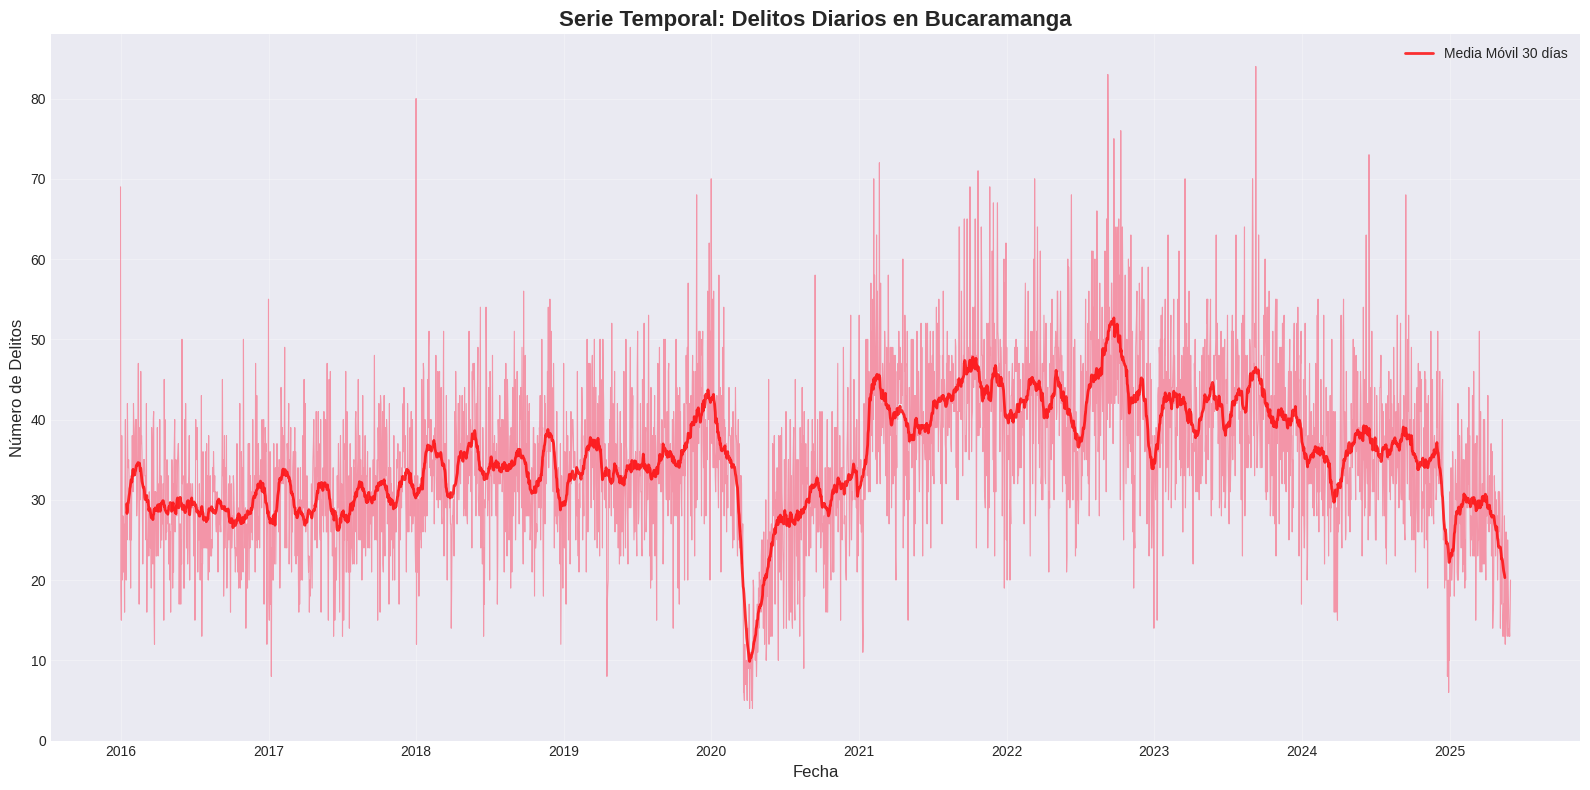

📈 Serie temporal visualizada con promedio móvil


In [5]:
# Visualizar la serie temporal
fig = plt.figure(figsize=FIGSIZE_LARGE)

plt.plot(ts_data['ds'], ts_data['y'], linewidth=0.8, alpha=0.7)
plt.title('Serie Temporal: Delitos Diarios en Bucaramanga', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Delitos', fontsize=12)
plt.grid(True, alpha=0.3)

# Promedio móvil de 30 días
ts_data['ma_30'] = ts_data['y'].rolling(window=30, center=True).mean()
plt.plot(ts_data['ds'], ts_data['ma_30'], 'r-', linewidth=2, label='Media Móvil 30 días', alpha=0.8)

plt.legend()
plt.tight_layout()
plt.show()

print(f"📈 Serie temporal visualizada con promedio móvil")


## 5. Modelo SARIMA <a id='5-sarima'></a>

SARIMA (Seasonal ARIMA) es un modelo clásico de series temporales que extiende ARIMA incorporando componentes estacionales.



Lo utilizaremos como **modelo de referencia** para comparar contra Prophet sobre la misma serie diaria de delitos, manteniendo el mismo esquema de entrenamiento y validación temporal.

MODELO SARIMA: PREPARACIÓN Y DIAGNÓSTICO

📊 Información básica de la serie:
   Registros: 3,439 días
   Rango: 2016-01-01 a 2025-05-31
   Media: 35.10 delitos/día
   Desv. estándar: 10.48

🔍 Test de Dickey-Fuller Aumentado (ADF):
   Estadístico ADF: -3.4993
   p-value: 0.0080
   Valores críticos: {'1%': np.float64(-3.4322685658061025), '5%': np.float64(-2.862387711732507), '10%': np.float64(-2.567221252861966)}
   ✅ Serie estacionaria (p ≤ 0.05)
   ➡️ No se requiere diferenciación (d=0)

📊 Descomposición de la serie temporal...
   Estadístico ADF: -3.4993
   p-value: 0.0080
   Valores críticos: {'1%': np.float64(-3.4322685658061025), '5%': np.float64(-2.862387711732507), '10%': np.float64(-2.567221252861966)}
   ✅ Serie estacionaria (p ≤ 0.05)
   ➡️ No se requiere diferenciación (d=0)

📊 Descomposición de la serie temporal...


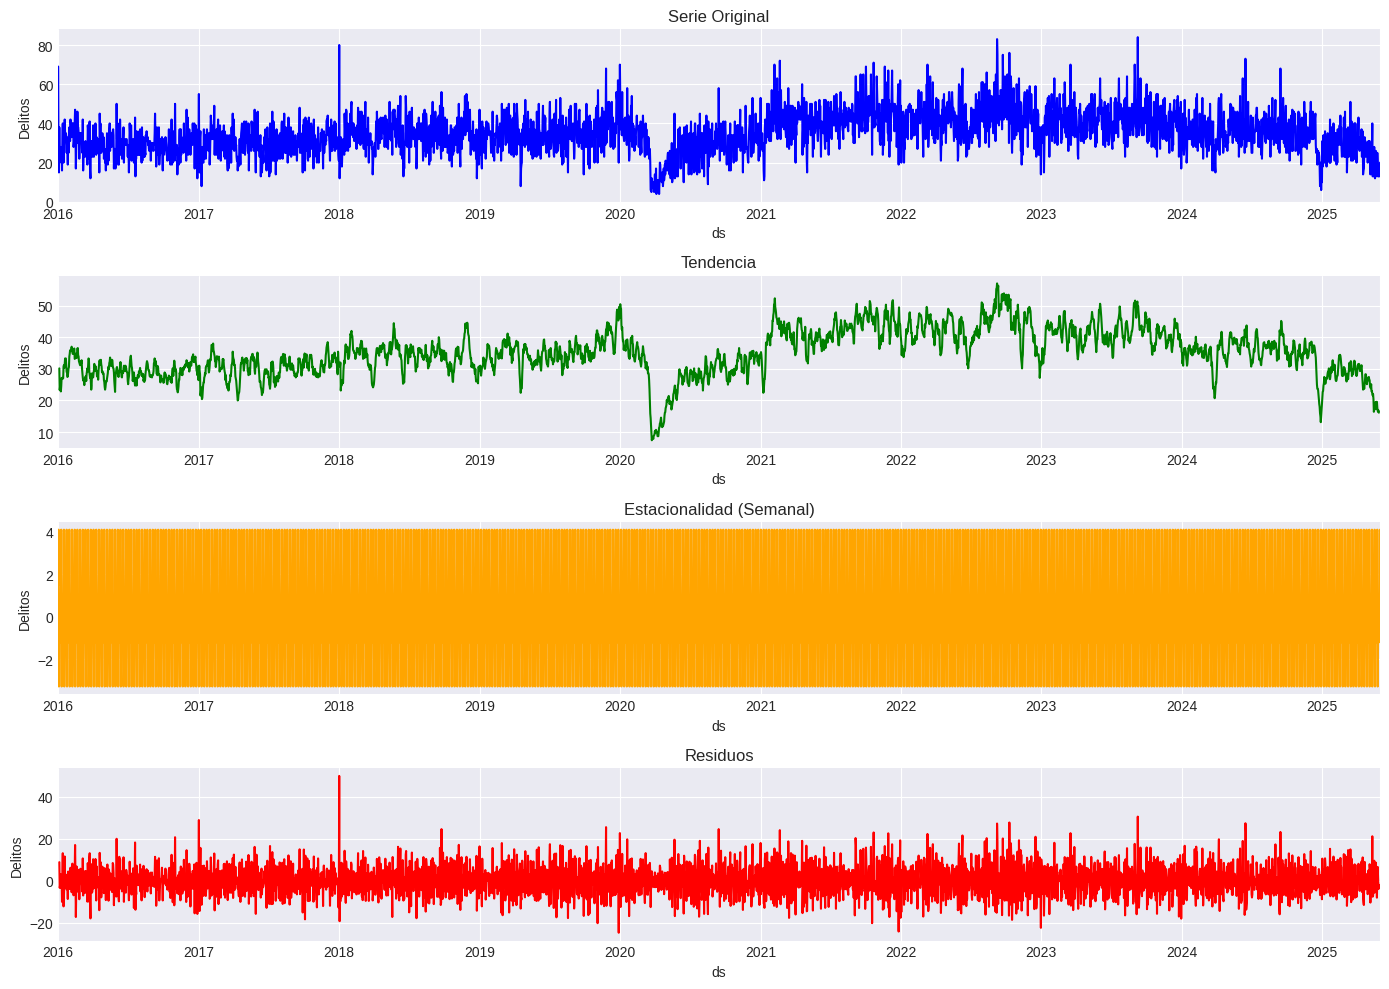

✅ Descomposición completada

💡 Interpretación:
   • Tendencia: Comportamiento general a largo plazo
   • Estacionalidad: Patrón semanal repetitivo
   • Residuos: Variación no explicada por tendencia/estacionalidad


In [6]:
# ============================================================================
# MODELO SARIMA: PREPARACIÓN Y DIAGNÓSTICO
# ============================================================================
print("=" * 80)
print("MODELO SARIMA: PREPARACIÓN Y DIAGNÓSTICO")
print("=" * 80)

# Usar la misma serie diaria agregada que para Prophet
ts_sarima = ts_data.copy()
ts_sarima = ts_sarima.set_index("ds")

print("\n📊 Información básica de la serie:")
print(f"   Registros: {len(ts_sarima):,} días")
print(f"   Rango: {ts_sarima.index.min().date()} a {ts_sarima.index.max().date()}")
print(f"   Media: {ts_sarima['y'].mean():.2f} delitos/día")
print(f"   Desv. estándar: {ts_sarima['y'].std():.2f}")

# Prueba de estacionariedad (ADF)
print("\n🔍 Test de Dickey-Fuller Aumentado (ADF):")
adf_result = adfuller(ts_sarima["y"])
print(f"   Estadístico ADF: {adf_result[0]:.4f}")
print(f"   p-value: {adf_result[1]:.4f}")
print(f"   Valores críticos: {adf_result[4]}")

if adf_result[1] > 0.05:
    print("   ❌ Serie NO estacionaria (p > 0.05)")
    print("   ➡️ SARIMA aplicará diferenciación automática (d=1)")
    d_order = 1
else:
    print("   ✅ Serie estacionaria (p ≤ 0.05)")
    print("   ➡️ No se requiere diferenciación (d=0)")
    d_order = 0

# Visualizar descomposición estacional
print("\n📊 Descomposición de la serie temporal...")
decomposition = seasonal_decompose(ts_sarima["y"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title="Serie Original", color="blue")
axes[0].set_ylabel("Delitos")
decomposition.trend.plot(ax=axes[1], title="Tendencia", color="green")
axes[1].set_ylabel("Delitos")
decomposition.seasonal.plot(ax=axes[2], title="Estacionalidad (Semanal)", color="orange")
axes[2].set_ylabel("Delitos")
decomposition.resid.plot(ax=axes[3], title="Residuos", color="red")
axes[3].set_ylabel("Delitos")
plt.tight_layout()
plt.show()

print("✅ Descomposición completada")
print("\n💡 Interpretación:")
print("   • Tendencia: Comportamiento general a largo plazo")
print("   • Estacionalidad: Patrón semanal repetitivo")
print("   • Residuos: Variación no explicada por tendencia/estacionalidad")

MODELO SARIMA: ENTRENAMIENTO Y PREDICCIÓN

📊 Configuración de predicción:
   Datos de entrenamiento: 3,439 días
   Última fecha histórica: 2025-05-31
   Días a predecir: 30

🔧 Parámetros del modelo:
   order (p,d,q) = (1, 0, 1)
   seasonal_order (P,D,Q,s) = (1, 1, 1, 7)

🚀 Entrenando modelo SARIMA...
✅ Modelo SARIMA entrenado

🔮 Generando predicciones...
✅ Predicciones generadas para 30 días
   Rango de predicción: 2025-06-01 a 2025-06-30
   Promedio predicho: 21.65 delitos/día
   Mínimo predicho: 17.06 delitos/día
   Máximo predicho: 30.03 delitos/día
✅ Modelo SARIMA entrenado

🔮 Generando predicciones...
✅ Predicciones generadas para 30 días
   Rango de predicción: 2025-06-01 a 2025-06-30
   Promedio predicho: 21.65 delitos/día
   Mínimo predicho: 17.06 delitos/día
   Máximo predicho: 30.03 delitos/día


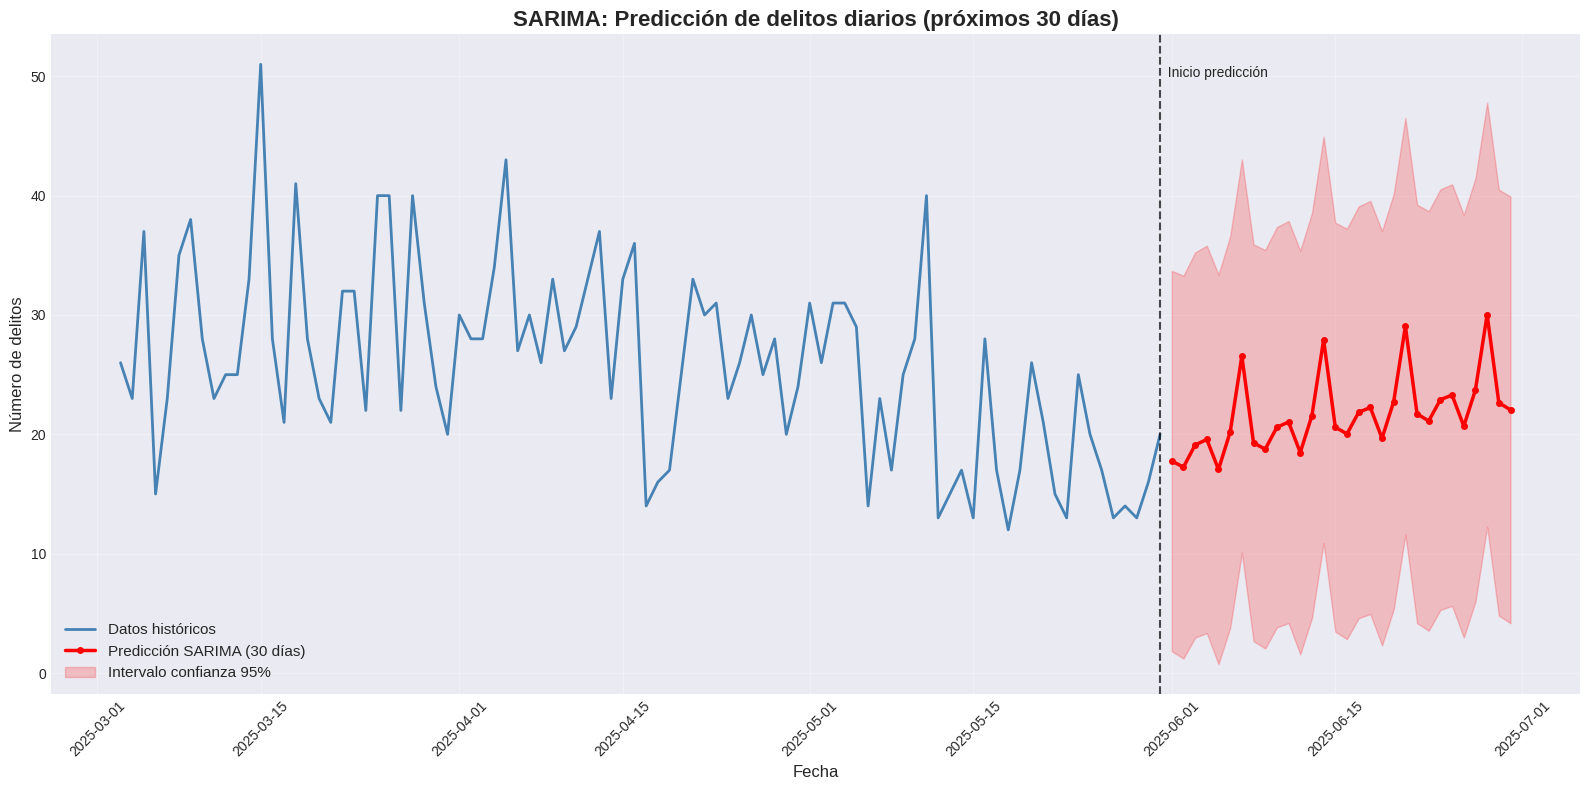


✅ Predicción SARIMA completada


In [7]:
# ============================================================================
# MODELO SARIMA: ENTRENAMIENTO Y PREDICCIÓN
# ============================================================================
print("=" * 80)
print("MODELO SARIMA: ENTRENAMIENTO Y PREDICCIÓN")
print("=" * 80)

# Usar el MISMO esquema de validación que Prophet para comparación justa
# Entrenar con TODA la serie histórica y predecir los próximos 30 días
future_days = 30

print("\n📊 Configuración de predicción:")
print(f"   Datos de entrenamiento: {len(ts_sarima):,} días")
print(f"   Última fecha histórica: {ts_sarima.index.max().date()}")
print(f"   Días a predecir: {future_days}")

# Órdenes del modelo SARIMA
order = (1, d_order, 1)           # (p, d, q)
seasonal_order = (1, 1, 1, 7)     # (P, D, Q, s) con s=7 (estacionalidad semanal)

print("\n🔧 Parámetros del modelo:")
print(f"   order (p,d,q) = {order}")
print(f"   seasonal_order (P,D,Q,s) = {seasonal_order}")

# Entrenar modelo SARIMAX con TODA la serie
print("\n🚀 Entrenando modelo SARIMA...")
sarima_model = SARIMAX(
    ts_sarima["y"],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_result = sarima_model.fit(disp=False)
print("✅ Modelo SARIMA entrenado")

# Generar predicciones para los próximos 30 días
print("\n🔮 Generando predicciones...")
sarima_forecast = sarima_result.get_forecast(steps=future_days)
sarima_pred = sarima_forecast.predicted_mean
sarima_conf_int = sarima_forecast.conf_int(alpha=0.05)

# Forzar no-negatividad en las predicciones
sarima_pred_clean = np.maximum(sarima_pred.values, 0)

print(f"✅ Predicciones generadas para {future_days} días")
print(f"   Rango de predicción: {sarima_pred.index[0].date()} a {sarima_pred.index[-1].date()}")
print(f"   Promedio predicho: {sarima_pred_clean.mean():.2f} delitos/día")
print(f"   Mínimo predicho: {sarima_pred_clean.min():.2f} delitos/día")
print(f"   Máximo predicho: {sarima_pred_clean.max():.2f} delitos/día")

# Visualización de predicciones
fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

# Mostrar últimos 90 días de histórico + predicción
last_n_days = 90
historical_window = ts_sarima.tail(last_n_days)

ax.plot(historical_window.index, historical_window["y"], 
        label="Datos históricos", color="steelblue", linewidth=2)
ax.plot(sarima_pred.index, sarima_pred_clean, 
        label=f"Predicción SARIMA ({future_days} días)", 
        color="red", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(
    sarima_pred.index,
    np.maximum(sarima_conf_int.iloc[:, 0].values, 0),
    np.maximum(sarima_conf_int.iloc[:, 1].values, 0),
    color="red",
    alpha=0.2,
    label="Intervalo confianza 95%",
)

# Línea vertical separando histórico de predicción
ax.axvline(ts_sarima.index.max(), color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(ts_sarima.index.max(), ax.get_ylim()[1] * 0.95, 
        "  Inicio predicción", rotation=0, va="top")

ax.set_title(f"SARIMA: Predicción de delitos diarios (próximos {future_days} días)", 
             fontsize=16, fontweight="bold")
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Número de delitos", fontsize=12)
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Predicción SARIMA completada")

## 6. Modelo Prophet <a id='6-prophet'></a>

Prophet es un modelo de series temporales desarrollado por Facebook que maneja automáticamente:
- Tendencias
- Estacionalidades múltiples (anual, semanal, diaria)
- Festivos y eventos especiales
- Valores faltantes

**Ventajas para nuestro caso:**
- ✅ Fácil de usar e interpretar
- ✅ Maneja automáticamente estacionalidad
- ✅ Robusto a datos faltantes
- ✅ Incorpora festivos colombianos

MODELO PROPHET MEJORADO: ENTRENAMIENTO Y PREDICCIÓN

🔍 Paso 1: Detección de outliers...
   Outliers detectados: 0 días (0.0%)
   Rango normal: [-14, 84] delitos/día

📊 Paso 2: Creando regresores externos...
   Regresores añadidos:
   • Días de la semana (lunes a domingo)
   • Efecto quincena 1 (días 12-17 del mes)
   • Efecto quincena 2 (últimos 3 días + primeros 2 días del mes)
   • Fin de semana, inicio/fin de mes, temporada vacacional

🔧 Paso 3: Configurando modelo Prophet mejorado...
✅ Modelo configurado con:
   • Changepoint prior scale: 0.15 (más flexible)
   • Seasonality mode: additive
   • Estacionalidades: anual, semanal, mensual, trimestral
   • Festivos: Colombia
   • Regresores días semana: lunes-domingo (7)
   • Regresores quincenas: efecto pago (2)
   • Otros regresores: fin de semana, inicio/fin mes, temporada (4)

🚀 Paso 4: Entrenando modelo Prophet mejorado...
   Entrenando con 3,439 registros...
   Total de regresores: 13
✅ Modelo configurado con:
   • Changepoint pr

22:55:08 - cmdstanpy - INFO - Chain [1] start processing
22:55:11 - cmdstanpy - INFO - Chain [1] done processing
22:55:11 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo entrenado exitosamente

🔮 Paso 5: Generando predicciones...
✅ Predicciones generadas para 30 días
   Rango: 2025-06-01 a 2025-06-30
   Promedio predicho: 24.06 delitos/día
   Mínimo predicho: 5.65 delitos/día
   Máximo predicho: 31.17 delitos/día

📊 Paso 6: Generando visualización...
✅ Predicciones generadas para 30 días
   Rango: 2025-06-01 a 2025-06-30
   Promedio predicho: 24.06 delitos/día
   Mínimo predicho: 5.65 delitos/día
   Máximo predicho: 31.17 delitos/día

📊 Paso 6: Generando visualización...


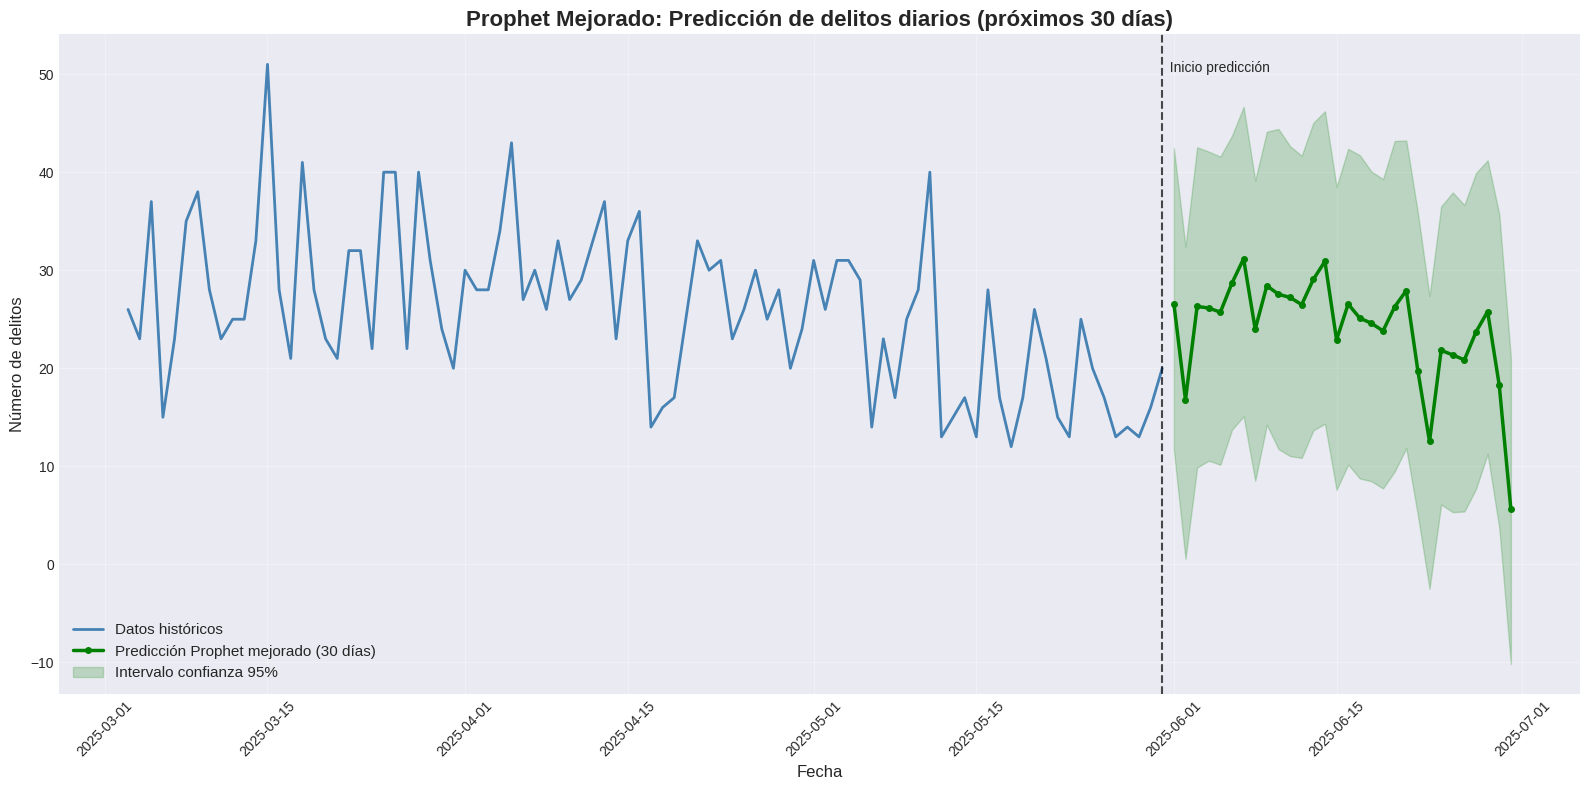


✅ MODELO PROPHET MEJORADO COMPLETADO


In [8]:
# ============================================================================
# MODELO PROPHET MEJORADO - CONFIGURACIÓN OPTIMIZADA
# ============================================================================
print("=" * 80)
print("MODELO PROPHET MEJORADO: ENTRENAMIENTO Y PREDICCIÓN")
print("=" * 80)

# MEJORAS IMPLEMENTADAS:
# 1. Detección automática de outliers y su tratamiento
# 2. Estacionalidades personalizadas (mensual y trimestral)
# 3. Regresores externos (días de la semana, quincenas, fin de semana, temporadas)
# 4. Ajuste de hiperparámetros para mejor ajuste

# Paso 1: Detectar y marcar outliers en la serie
print("\n🔍 Paso 1: Detección de outliers...")
Q1 = ts_data['y'].quantile(0.25)
Q3 = ts_data['y'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers_mask = (ts_data['y'] < lower_bound) | (ts_data['y'] > upper_bound)
num_outliers = outliers_mask.sum()
print(f"   Outliers detectados: {num_outliers} días ({num_outliers/len(ts_data)*100:.1f}%)")
print(f"   Rango normal: [{lower_bound:.0f}, {upper_bound:.0f}] delitos/día")

# Crear serie limpia para entrenamiento (suavizar outliers)
ts_data_clean = ts_data.copy()
ts_data_clean.loc[outliers_mask, 'y'] = ts_data['y'].median()

# Paso 2: Añadir regresores externos
print("\n📊 Paso 2: Creando regresores externos...")

# Días de la semana (one-hot encoding)
ts_data_clean['day_of_week'] = ts_data_clean['ds'].dt.dayofweek
for i in range(7):
    day_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
    ts_data_clean[day_names[i]] = (ts_data_clean['day_of_week'] == i).astype(int)

# Efecto de pago de quincenas
# Quincena 1: día 15 del mes
# Quincena 2: último día del mes
# Periodo de influencia: 3 días antes y 2 días después del pago
ts_data_clean['day_of_month'] = ts_data_clean['ds'].dt.day
ts_data_clean['days_in_month'] = ts_data_clean['ds'].dt.days_in_month
ts_data_clean['is_last_day'] = (ts_data_clean['day_of_month'] == ts_data_clean['days_in_month']).astype(int)

# Periodo de quincena 1 (días 12-17)
ts_data_clean['quincena_1'] = ((ts_data_clean['day_of_month'] >= 12) & 
                                (ts_data_clean['day_of_month'] <= 17)).astype(int)

# Periodo de quincena 2 (últimos 3 días del mes + primeros 2 del siguiente)
# Para los últimos días del mes
ts_data_clean['quincena_2'] = (ts_data_clean['day_of_month'] >= 
                                (ts_data_clean['days_in_month'] - 2)).astype(int)
# Para los primeros días del mes (efecto residual)
ts_data_clean['quincena_2'] = ts_data_clean['quincena_2'] | (ts_data_clean['day_of_month'] <= 2).astype(int)
ts_data_clean['quincena_2'] = ts_data_clean['quincena_2'].astype(int)

# Otros regresores
ts_data_clean['is_weekend'] = (ts_data_clean['ds'].dt.dayofweek >= 5).astype(int)
ts_data_clean['is_month_start'] = ts_data_clean['ds'].dt.is_month_start.astype(int)
ts_data_clean['is_month_end'] = ts_data_clean['ds'].dt.is_month_end.astype(int)
ts_data_clean['month'] = ts_data_clean['ds'].dt.month
ts_data_clean['is_holiday_season'] = ts_data_clean['month'].isin([12, 1, 6, 7]).astype(int)

print("   Regresores añadidos:")
print("   • Días de la semana (lunes a domingo)")
print("   • Efecto quincena 1 (días 12-17 del mes)")
print("   • Efecto quincena 2 (últimos 3 días + primeros 2 días del mes)")
print("   • Fin de semana, inicio/fin de mes, temporada vacacional")

# Paso 3: Configurar modelo Prophet mejorado
print("\n🔧 Paso 3: Configurando modelo Prophet mejorado...")
model_prophet = Prophet(
    # Parámetros de tendencia
    changepoint_prior_scale=0.15,      # Más flexible que 0.05 (captura cambios mejor)
    n_changepoints=25,                  # Más puntos de cambio detectables
    changepoint_range=0.9,              # Considerar 90% de datos para changepoints
    
    # Parámetros de estacionalidad
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,            
    seasonality_mode='additive',   
    seasonality_prior_scale=8.0,        # Ajustado para evitar sobreajuste
    
    # Intervalo de confianza
    interval_width=0.95,
    
    # Configuración de incertidumbre
    mcmc_samples=0,                     # 0 = MAP, >0 = MCMC (más lento pero mejor IC)
    uncertainty_samples=1000,           # Muestras para IC
)

# Añadir festivos colombianos
model_prophet.add_country_holidays(country_name='CO')

# Añadir estacionalidades personalizadas
model_prophet.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5,
    prior_scale=5.0
)
model_prophet.add_seasonality(
    name='quarterly', 
    period=91.25,
    fourier_order=3,
    prior_scale=3.0
)

# Añadir regresores de días de la semana
day_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
for day in day_names:
    model_prophet.add_regressor(day, prior_scale=0.5, standardize=True)

# Añadir regresores de quincenas (efecto de pago de sueldos)
model_prophet.add_regressor('quincena_1', prior_scale=1.0, standardize=True)
model_prophet.add_regressor('quincena_2', prior_scale=1.0, standardize=True)

# Añadir otros regresores
model_prophet.add_regressor('is_weekend', prior_scale=0.5)
model_prophet.add_regressor('is_month_start', prior_scale=0.3)
model_prophet.add_regressor('is_month_end', prior_scale=0.3)
model_prophet.add_regressor('is_holiday_season', prior_scale=0.5)

print("✅ Modelo configurado con:")
print("   • Changepoint prior scale: 0.15 (más flexible)")
print("   • Seasonality mode: additive")
print("   • Estacionalidades: anual, semanal, mensual, trimestral")
print("   • Festivos: Colombia")
print("   • Regresores días semana: lunes-domingo (7)")
print("   • Regresores quincenas: efecto pago (2)")
print("   • Otros regresores: fin de semana, inicio/fin mes, temporada (4)")

# Paso 4: Entrenar modelo
print("\n🚀 Paso 4: Entrenando modelo Prophet mejorado...")

# Seleccionar solo las columnas necesarias para el entrenamiento
train_cols = ['ds', 'y'] + day_names + ['quincena_1', 'quincena_2', 
                                         'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday_season']
df_train = ts_data_clean[train_cols].copy()

# Verificar que no haya valores nulos
if df_train.isnull().any().any():
    print("⚠️ Advertencia: Hay valores nulos. Rellenando...")
    df_train = df_train.fillna(method='ffill').fillna(method='bfill')

print(f"   Entrenando con {len(df_train):,} registros...")
print(f"   Total de regresores: {len(train_cols) - 2}")  # -2 para ds y y
model_prophet.fit(df_train)
print("✅ Modelo entrenado exitosamente")

# Paso 5: Generar predicciones (30 días para comparar con SARIMA)
print("\n🔮 Paso 5: Generando predicciones...")
future_periods = 30
future = model_prophet.make_future_dataframe(periods=future_periods, freq='D')

# Añadir TODOS los regresores al futuro
# Días de la semana
future['day_of_week'] = future['ds'].dt.dayofweek
for i in range(7):
    future[day_names[i]] = (future['day_of_week'] == i).astype(int)

# Efecto de quincenas
future['day_of_month'] = future['ds'].dt.day
future['days_in_month'] = future['ds'].dt.days_in_month

future['quincena_1'] = ((future['day_of_month'] >= 12) & 
                        (future['day_of_month'] <= 17)).astype(int)

future['quincena_2'] = (future['day_of_month'] >= 
                        (future['days_in_month'] - 2)).astype(int)
future['quincena_2'] = future['quincena_2'] | (future['day_of_month'] <= 2).astype(int)
future['quincena_2'] = future['quincena_2'].astype(int)

# Otros regresores
future['is_weekend'] = (future['ds'].dt.dayofweek >= 5).astype(int)
future['is_month_start'] = future['ds'].dt.is_month_start.astype(int)
future['is_month_end'] = future['ds'].dt.is_month_end.astype(int)
future['month'] = future['ds'].dt.month
future['is_holiday_season'] = future['month'].isin([12, 1, 6, 7]).astype(int)

forecast = model_prophet.predict(future)

# Extraer predicciones futuras
forecast_future_30d = forecast.tail(future_periods).copy()
prophet_pred_30d = forecast_future_30d['yhat'].values

print(f"✅ Predicciones generadas para {future_periods} días")
print(f"   Rango: {forecast_future_30d['ds'].min().date()} a {forecast_future_30d['ds'].max().date()}")
print(f"   Promedio predicho: {prophet_pred_30d.mean():.2f} delitos/día")
print(f"   Mínimo predicho: {prophet_pred_30d.min():.2f} delitos/día")
print(f"   Máximo predicho: {prophet_pred_30d.max():.2f} delitos/día")

# Paso 6: Visualización
print("\n📊 Paso 6: Generando visualización...")
fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

# Mostrar últimos 90 días de histórico + predicción
last_n_days = 90
historical_window = ts_data.tail(last_n_days)

ax.plot(historical_window['ds'], historical_window['y'], 
        label='Datos históricos', color='steelblue', linewidth=2)
ax.plot(forecast_future_30d['ds'], forecast_future_30d['yhat'], 
        label=f'Predicción Prophet mejorado ({future_periods} días)', 
        color='green', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(
    forecast_future_30d['ds'],
    forecast_future_30d['yhat_lower'],
    forecast_future_30d['yhat_upper'],
    color='green',
    alpha=0.2,
    label='Intervalo confianza 95%',
)

# Línea vertical separando histórico de predicción
ax.axvline(ts_data['ds'].max(), color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(ts_data['ds'].max(), ax.get_ylim()[1] * 0.95, 
        '  Inicio predicción', rotation=0, va='top')

ax.set_title(f'Prophet Mejorado: Predicción de delitos diarios (próximos {future_periods} días)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Número de delitos', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ MODELO PROPHET MEJORADO COMPLETADO")
print("="*80)

ANÁLISIS DE CONTRIBUCIÓN DE REGRESORES

📊 Analizando contribución de regresores externos:

   Total de regresores configurados: 13
   Regresores: monday, tuesday, wednesday, thursday, friday, saturday, sunday, quincena_1, quincena_2, is_weekend, is_month_start, is_month_end, is_holiday_season

🗓️  DÍAS DE LA SEMANA (efecto relativo):
   Lunes       :  +0.416 (efecto relativo) ↑
   Martes      :  +0.219 (efecto relativo) ↑
   Miércoles   :  +0.146 (efecto relativo) ↑
   Jueves      :  +0.012 (efecto relativo) ↑
   Viernes     :  +0.606 (efecto relativo) ↑
   Sábado      :  +0.102 (efecto relativo) ↑
   Domingo     :  -1.502 (efecto relativo) ↓

💰 EFECTO DE PAGO DE QUINCENAS:
   Quincena 1 (días 12-17):       +0.019 (efecto relativo) ↑
   Quincena 2 (fin/inicio mes):   +0.020 (efecto relativo) ↑

🎯 OTROS EFECTOS:
   Fin de semana         :  +0.000 (efecto relativo) =
   Inicio de mes         :  +4.134 (efecto relativo) ↑
   Fin de mes            :  +1.306 (efecto relativo) ↑
   Temporada

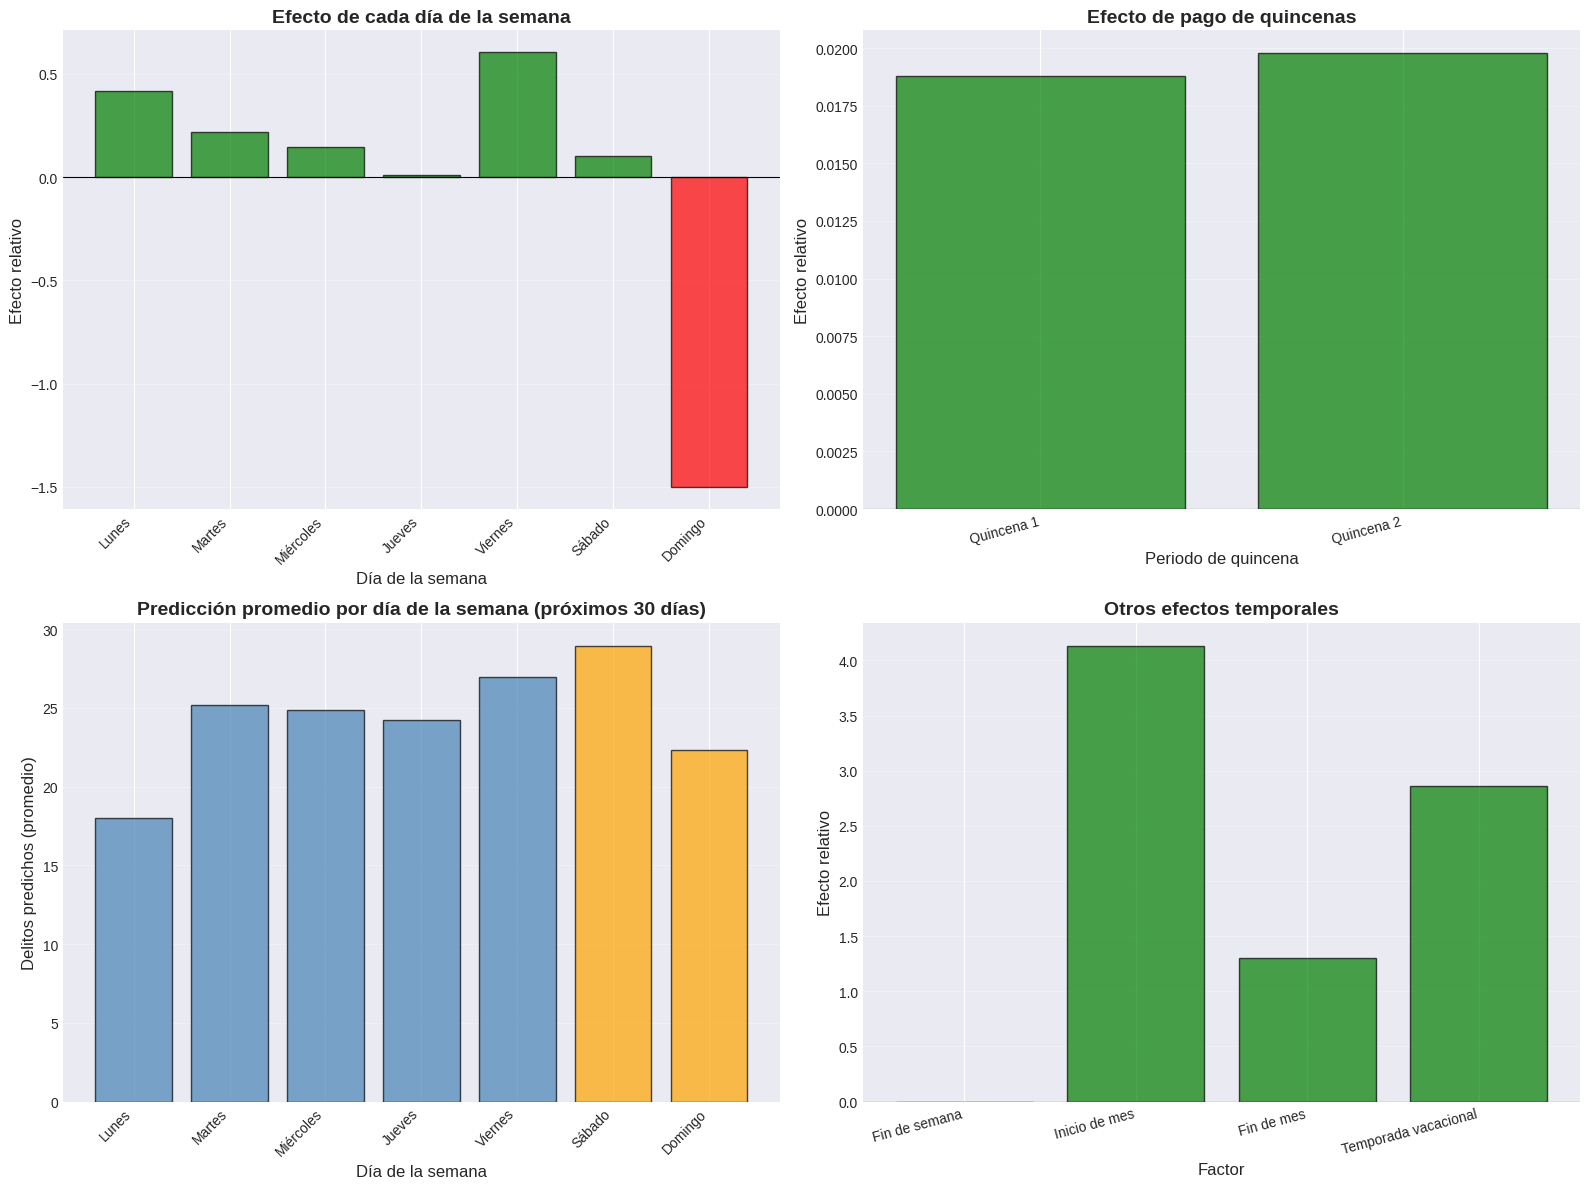


💡 INTERPRETACIÓN:
   • Estos valores muestran el EFECTO RELATIVO de cada regresor en el modelo
   • Valores positivos indican AUMENTO en delitos cuando el factor está presente
   • Valores negativos indican DISMINUCIÓN en delitos
   • Los efectos se suman a la tendencia base y estacionalidades del modelo
   • Las quincenas capturan el efecto del pago de sueldos en la actividad delictiva

✅ ANÁLISIS DE REGRESORES COMPLETADO


In [9]:
# ============================================================================
# ANÁLISIS DE IMPACTO DE REGRESORES
# ============================================================================
print("=" * 80)
print("ANÁLISIS DE CONTRIBUCIÓN DE REGRESORES")
print("=" * 80)

# Extraer componentes del forecast para analizar impacto
print("\n📊 Analizando contribución de regresores externos:\n")

# Crear un forecast completo para analizar componentes
forecast_full = model_prophet.predict(future)

# Obtener nombres de regresores extra
extra_regressors = model_prophet.extra_regressors.keys()

print(f"   Total de regresores configurados: {len(extra_regressors)}")
print(f"   Regresores: {', '.join(extra_regressors)}\n")

# Calcular estadísticas de impacto por regresor
# Para cada regresor, calcular su contribución promedio
day_names_en = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
day_names_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

print("🗓️  DÍAS DE LA SEMANA (efecto relativo):")

# Extraer efectos de días desde el forecast
day_effects = {}
for i, (day_en, day_es) in enumerate(zip(day_names_en, day_names_es)):
    if day_en in forecast_full.columns:
        # Calcular efecto promedio cuando ese día está activo
        day_data = forecast_full[forecast_full['ds'].dt.dayofweek == i]
        if len(day_data) > 0:
            effect = day_data[day_en].mean() if day_en in day_data.columns else 0
            day_effects[day_es] = effect
            sign = "↑" if effect > 0 else "↓" if effect < 0 else "="
            print(f"   {day_es:12s}: {effect:+7.3f} (efecto relativo) {sign}")
        else:
            day_effects[day_es] = 0
            print(f"   {day_es:12s}: sin datos suficientes")

# Efectos de quincenas
print("\n💰 EFECTO DE PAGO DE QUINCENAS:")
quincena_effects = {}

if 'quincena_1' in forecast_full.columns:
    q1_data = forecast_full[forecast_full['quincena_1'] > 0]
    q1_effect = q1_data['quincena_1'].mean() if len(q1_data) > 0 else 0
    quincena_effects['Quincena 1'] = q1_effect
    sign1 = "↑" if q1_effect > 0 else "↓" if q1_effect < 0 else "="
    print(f"   Quincena 1 (días 12-17):      {q1_effect:+7.3f} (efecto relativo) {sign1}")
    
if 'quincena_2' in forecast_full.columns:
    q2_data = forecast_full[forecast_full['quincena_2'] > 0]
    q2_effect = q2_data['quincena_2'].mean() if len(q2_data) > 0 else 0
    quincena_effects['Quincena 2'] = q2_effect
    sign2 = "↑" if q2_effect > 0 else "↓" if q2_effect < 0 else "="
    print(f"   Quincena 2 (fin/inicio mes):  {q2_effect:+7.3f} (efecto relativo) {sign2}")

# Otros efectos
print("\n🎯 OTROS EFECTOS:")
other_effects = {}
other_regressors = {
    'is_weekend': 'Fin de semana',
    'is_month_start': 'Inicio de mes',
    'is_month_end': 'Fin de mes',
    'is_holiday_season': 'Temporada vacacional'
}

for reg_en, reg_es in other_regressors.items():
    if reg_en in forecast_full.columns:
        reg_data = forecast_full[forecast_full[reg_en] > 0]
        effect = reg_data[reg_en].mean() if len(reg_data) > 0 else 0
        other_effects[reg_es] = effect
        sign = "↑" if effect > 0 else "↓" if effect < 0 else "="
        print(f"   {reg_es:22s}: {effect:+7.3f} (efecto relativo) {sign}")

# Visualización de efectos
print("\n📈 Generando visualización de efectos...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Efecto de días de la semana
ax1 = axes[0, 0]
days_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
effects_ordered = [day_effects.get(day, 0) for day in days_order]
colors_days = ['red' if e < 0 else 'green' if e > 0 else 'gray' for e in effects_ordered]

ax1.bar(days_order, effects_ordered, color=colors_days, alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_title('Efecto de cada día de la semana', fontsize=14, fontweight='bold')
ax1.set_xlabel('Día de la semana', fontsize=12)
ax1.set_ylabel('Efecto relativo', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Gráfico 2: Efecto de quincenas
ax2 = axes[0, 1]
if len(quincena_effects) > 0:
    q_labels = list(quincena_effects.keys())
    q_values = list(quincena_effects.values())
    colors_quinc = ['red' if e < 0 else 'green' if e > 0 else 'gray' for e in q_values]
    
    ax2.bar(q_labels, q_values, color=colors_quinc, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_title('Efecto de pago de quincenas', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Periodo de quincena', fontsize=12)
    ax2.set_ylabel('Efecto relativo', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Gráfico 3: Predicción por día de la semana
ax3 = axes[1, 0]
forecast_30d = forecast_full.tail(30).copy()
forecast_30d['day_name'] = forecast_30d['ds'].dt.day_name()
day_avg = forecast_30d.groupby('day_name')['yhat'].mean()
day_avg = day_avg.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
day_avg.index = days_order

colors_pred = ['steelblue' if i < 5 else 'orange' for i in range(7)]
ax3.bar(day_avg.index, day_avg.values, color=colors_pred, alpha=0.7, edgecolor='black')
ax3.set_title('Predicción promedio por día de la semana (próximos 30 días)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Día de la semana', fontsize=12)
ax3.set_ylabel('Delitos predichos (promedio)', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Gráfico 4: Otros efectos combinados
ax4 = axes[1, 1]
if len(other_effects) > 0:
    o_labels = list(other_effects.keys())
    o_values = list(other_effects.values())
    colors_other = ['red' if e < 0 else 'green' if e > 0 else 'gray' for e in o_values]
    
    ax4.bar(o_labels, o_values, color=colors_other, alpha=0.7, edgecolor='black')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax4.set_title('Otros efectos temporales', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Factor', fontsize=12)
    ax4.set_ylabel('Efecto relativo', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

# Interpretación
print("\n💡 INTERPRETACIÓN:")
print("   • Estos valores muestran el EFECTO RELATIVO de cada regresor en el modelo")
print("   • Valores positivos indican AUMENTO en delitos cuando el factor está presente")
print("   • Valores negativos indican DISMINUCIÓN en delitos")
print("   • Los efectos se suman a la tendencia base y estacionalidades del modelo")
print("   • Las quincenas capturan el efecto del pago de sueldos en la actividad delictiva")

print("\n" + "="*80)
print("✅ ANÁLISIS DE REGRESORES COMPLETADO")
print("="*80)


COMPARACIÓN PROPHET VS SARIMA: PRÓXIMOS 30 DÍAS

📅 Rango de predicción:
   Desde: 2025-06-01
   Hasta: 2025-06-30


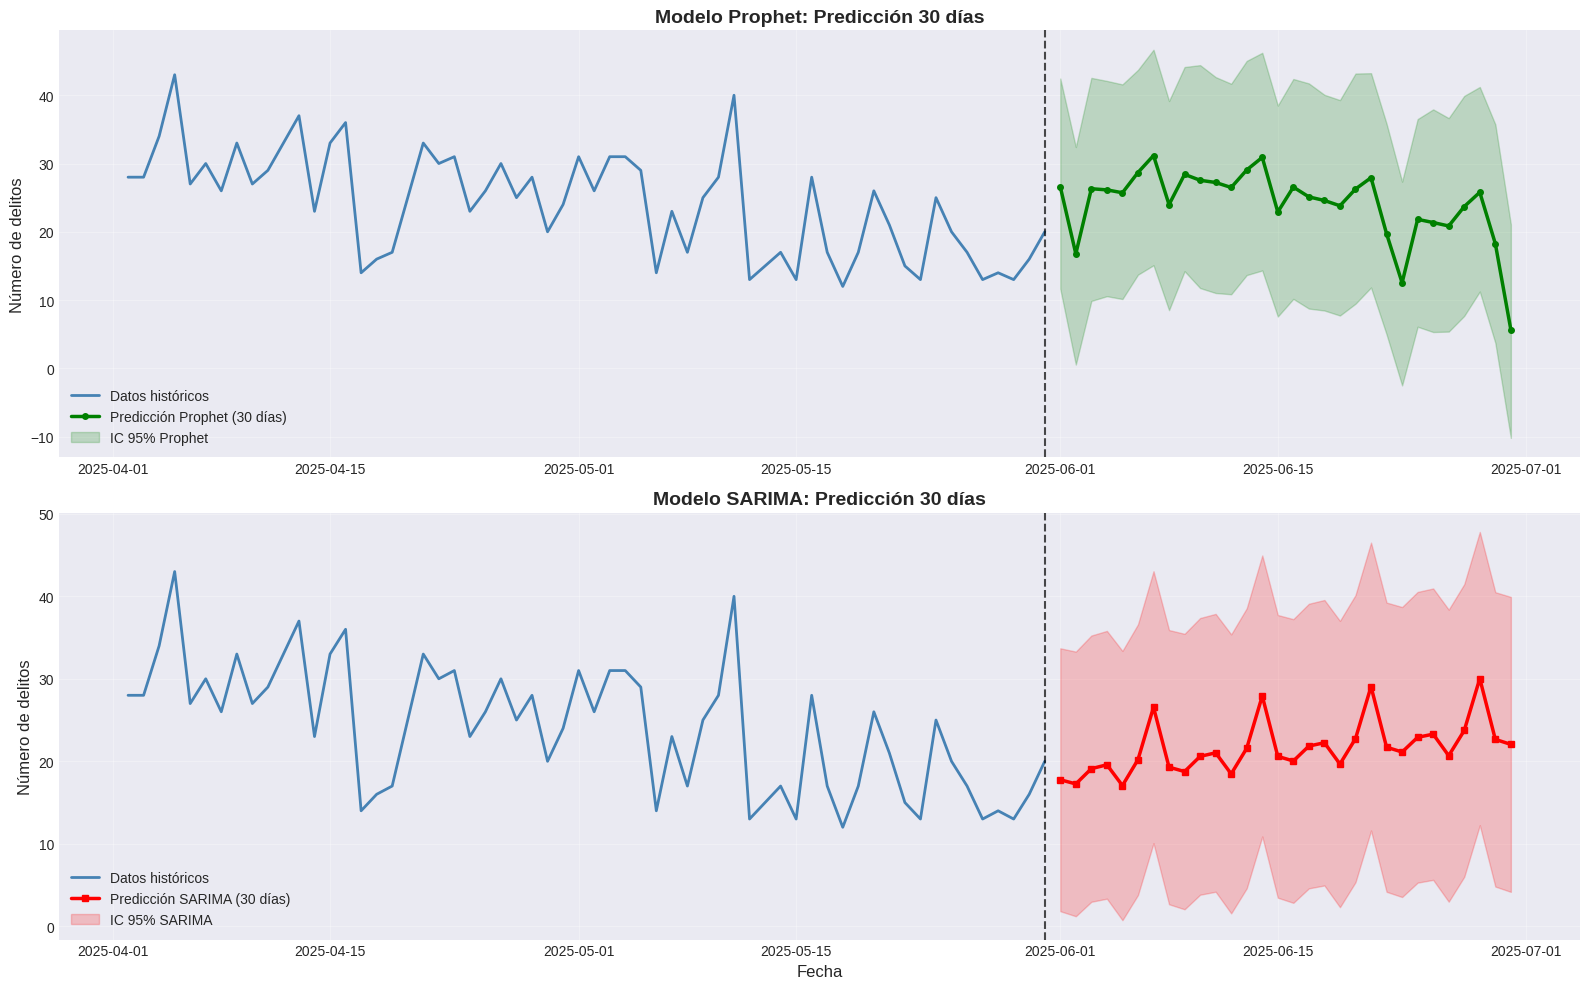


📊 COMPARACIÓN DE PREDICCIONES (30 días):

Prophet:
   Promedio: 24.06 delitos/día
   Mínimo:  5.65 delitos/día
   Máximo:   31.17 delitos/día
   Desv. est: 5.29

SARIMA:
   Promedio: 21.65 delitos/día
   Mínimo:  17.06 delitos/día
   Máximo:   30.03 delitos/día
   Desv. est: 3.18

🔄 Diferencia promedio: 2.41 delitos/día
   Prophet predice 2.41 delitos/día MÁS que SARIMA

✅ Comparación completada


In [10]:
# ============================================================================
# COMPARACIÓN VISUAL: PROPHET VS SARIMA (MISMO HORIZONTE)
# ============================================================================
print("=" * 80)
print("COMPARACIÓN PROPHET VS SARIMA: PRÓXIMOS 30 DÍAS")
print("=" * 80)

# Obtener predicciones de Prophet para los próximos 30 días
forecast_prophet_30d = forecast.tail(30).copy()

# Asegurar fechas alineadas
print("\n📅 Rango de predicción:")
print(f"   Desde: {sarima_pred.index[0].date()}")
print(f"   Hasta: {sarima_pred.index[-1].date()}")

# Comparación visual lado a lado
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Últimos 60 días de histórico para contexto
last_60_days = ts_data.tail(60)

# Subplot 1: Prophet
ax1 = axes[0]
ax1.plot(last_60_days["ds"], last_60_days["y"], 
         label="Datos históricos", color="steelblue", linewidth=2)
ax1.plot(forecast_prophet_30d["ds"], forecast_prophet_30d["yhat"], 
         label="Predicción Prophet (30 días)", 
         color="green", linewidth=2.5, marker="o", markersize=4)
ax1.fill_between(
    forecast_prophet_30d["ds"],
    forecast_prophet_30d["yhat_lower"],
    forecast_prophet_30d["yhat_upper"],
    color="green",
    alpha=0.2,
    label="IC 95% Prophet",
)
ax1.axvline(ts_data["ds"].max(), color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax1.set_title("Modelo Prophet: Predicción 30 días", fontsize=14, fontweight="bold")
ax1.set_ylabel("Número de delitos", fontsize=12)
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# Subplot 2: SARIMA
ax2 = axes[1]
ax2.plot(last_60_days["ds"], last_60_days["y"], 
         label="Datos históricos", color="steelblue", linewidth=2)
ax2.plot(sarima_pred.index, np.maximum(sarima_pred.values, 0), 
         label="Predicción SARIMA (30 días)", 
         color="red", linewidth=2.5, marker="s", markersize=4)
ax2.fill_between(
    sarima_pred.index,
    np.maximum(sarima_conf_int.iloc[:, 0].values, 0),
    np.maximum(sarima_conf_int.iloc[:, 1].values, 0),
    color="red",
    alpha=0.2,
    label="IC 95% SARIMA",
)
ax2.axvline(ts_data["ds"].max(), color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.set_title("Modelo SARIMA: Predicción 30 días", fontsize=14, fontweight="bold")
ax2.set_xlabel("Fecha", fontsize=12)
ax2.set_ylabel("Número de delitos", fontsize=12)
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas comparativas
prophet_pred_30d = forecast_prophet_30d["yhat"].values
sarima_pred_30d = np.maximum(sarima_pred.values, 0)

print("\n📊 COMPARACIÓN DE PREDICCIONES (30 días):")
print("\nProphet:")
print(f"   Promedio: {prophet_pred_30d.mean():.2f} delitos/día")
print(f"   Mínimo:  {prophet_pred_30d.min():.2f} delitos/día")
print(f"   Máximo:   {prophet_pred_30d.max():.2f} delitos/día")
print(f"   Desv. est: {prophet_pred_30d.std():.2f}")

print("\nSARIMA:")
print(f"   Promedio: {sarima_pred_30d.mean():.2f} delitos/día")
print(f"   Mínimo:  {sarima_pred_30d.min():.2f} delitos/día")
print(f"   Máximo:   {sarima_pred_30d.max():.2f} delitos/día")
print(f"   Desv. est: {sarima_pred_30d.std():.2f}")

# Diferencia promedio
diff_avg = prophet_pred_30d.mean() - sarima_pred_30d.mean()
print(f"\n🔄 Diferencia promedio: {abs(diff_avg):.2f} delitos/día")
if diff_avg > 0:
    print(f"   Prophet predice {diff_avg:.2f} delitos/día MÁS que SARIMA")
else:
    print(f"   SARIMA predice {abs(diff_avg):.2f} delitos/día MÁS que Prophet")

print("\n✅ Comparación completada")

📊 Generando visualizaciones del modelo Prophet...



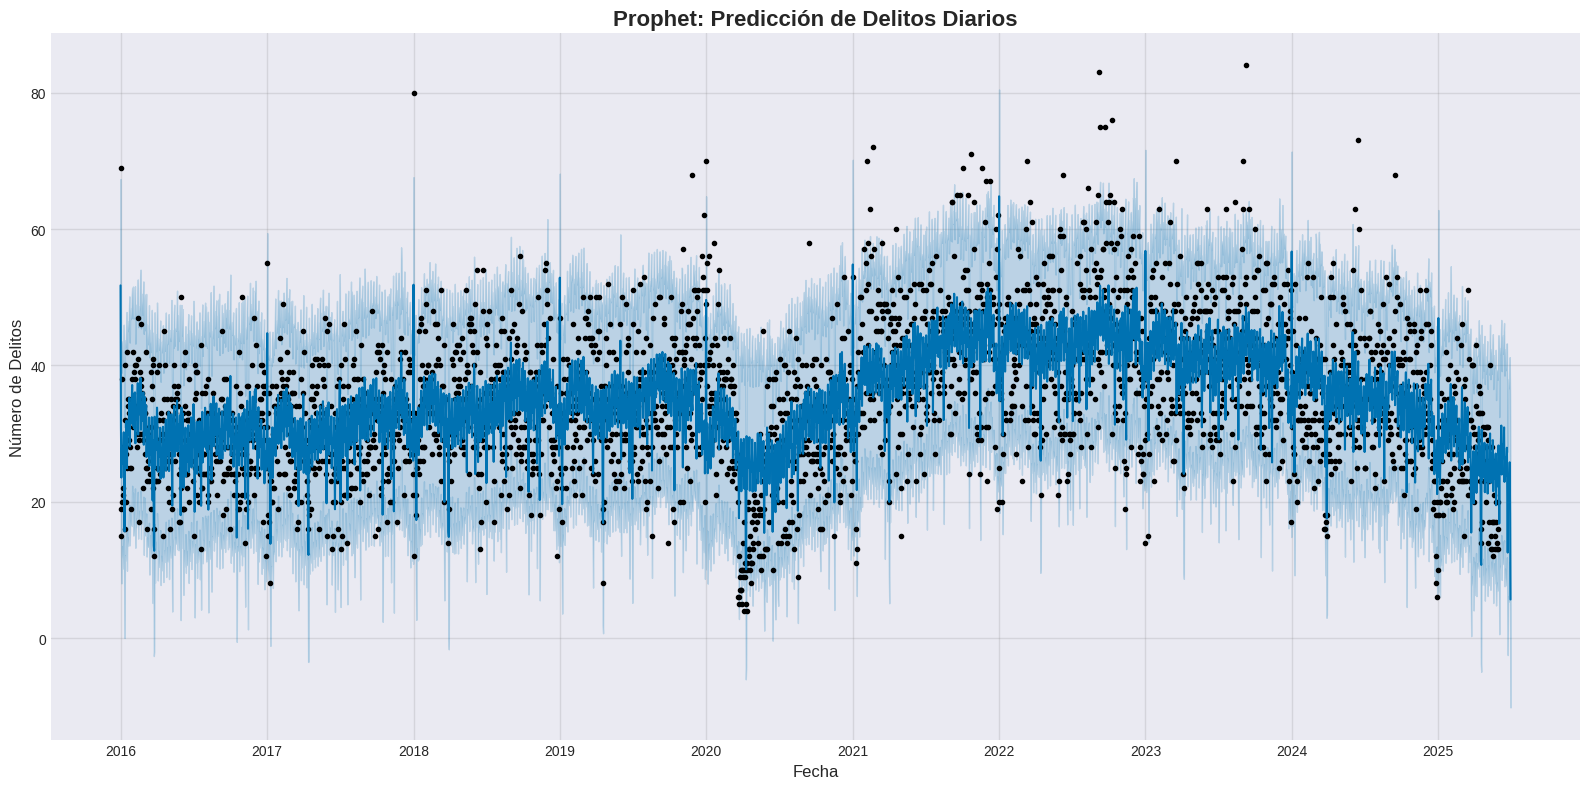

✅ Gráfico 1: Predicción completa (histórico + futuro)



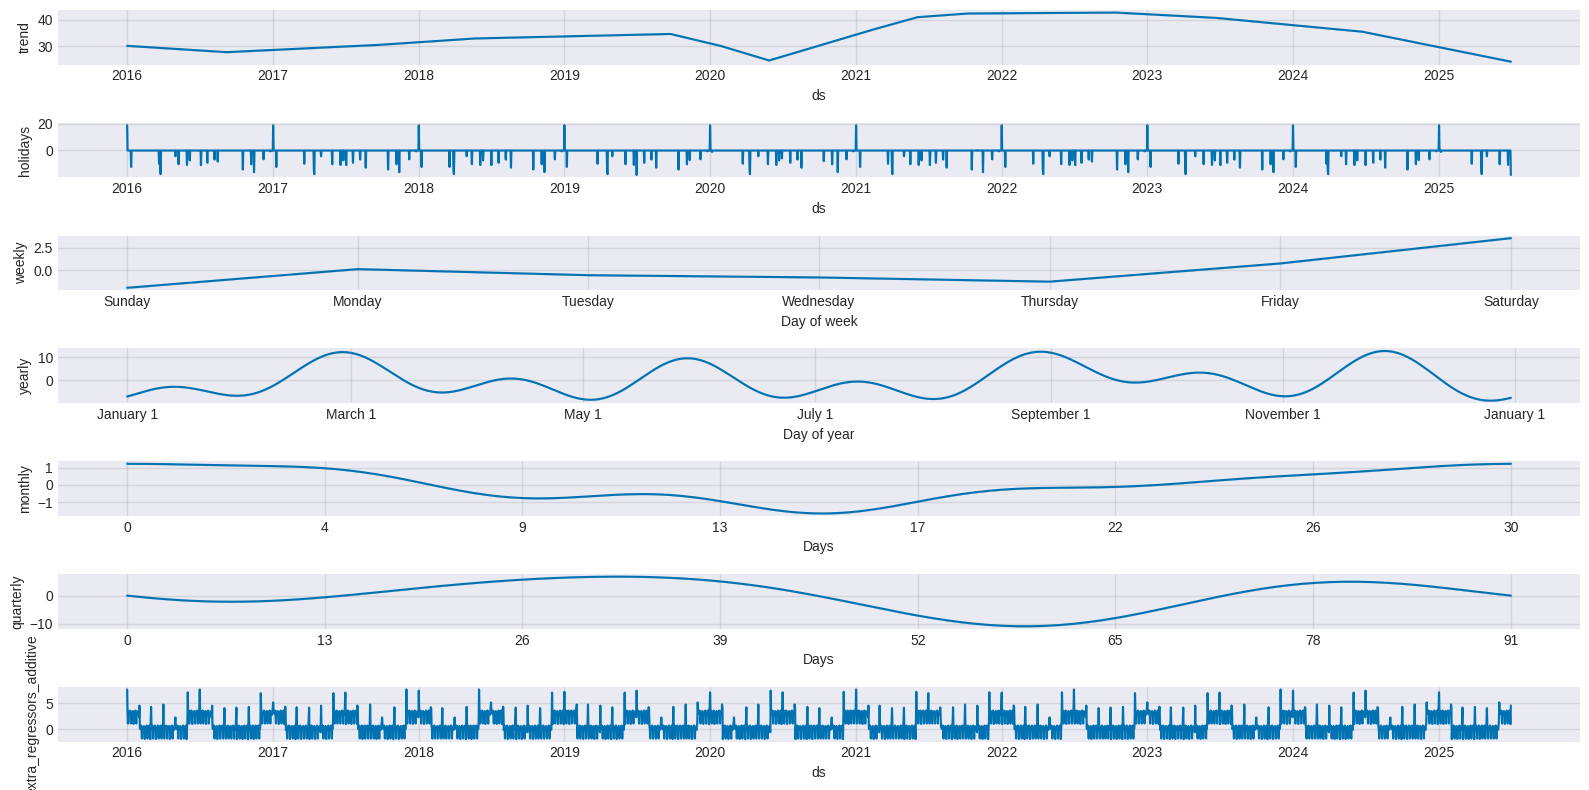

✅ Gráfico 2: Componentes del modelo
   • Tendencia general
   • Estacionalidad semanal
   • Estacionalidad anual
   • Efecto de festivos



In [11]:
# ============================================================================
# VISUALIZACIÓN DE PREDICCIONES PROPHET
# ============================================================================
print("📊 Generando visualizaciones del modelo Prophet...\n")

# 1. Gráfico principal: Datos históricos + Predicción
fig1 = model_prophet.plot(forecast, figsize=FIGSIZE_LARGE)
plt.title('Prophet: Predicción de Delitos Diarios', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Delitos', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Gráfico 1: Predicción completa (histórico + futuro)\n")

# 2. Componentes del modelo (tendencia + estacionalidades)
fig2 = model_prophet.plot_components(forecast, figsize=FIGSIZE_LARGE)
plt.tight_layout()
plt.show()

print("✅ Gráfico 2: Componentes del modelo")
print("   • Tendencia general")
print("   • Estacionalidad semanal")
print("   • Estacionalidad anual")
print("   • Efecto de festivos\n")


VALIDACIÓN DEL MODELO PROPHET

📊 División temporal:
   Train: 3,409 días (hasta 2025-05-01)
   Test: 30 días (últimos 30 días)

🔧 Re-entrenando modelo en datos de train...


22:55:17 - cmdstanpy - INFO - Chain [1] start processing
22:55:18 - cmdstanpy - INFO - Chain [1] done processing
22:55:18 - cmdstanpy - INFO - Chain [1] done processing



✅ Modelo validado

📊 MÉTRICAS DE EVALUACIÓN (30 días):
   MAE (Mean Absolute Error):  10.64 delitos/día
   RMSE (Root Mean Squared Error): 11.86 delitos/día
   MAPE (Mean Absolute % Error): 61.66%
   R² (Coeficiente determinación): -1.8656

📈 Interpretación:
   • En promedio, el modelo se equivoca por ±10.6 delitos al predecir un día
   • El modelo explica el -186.6% de la variabilidad en los delitos diarios


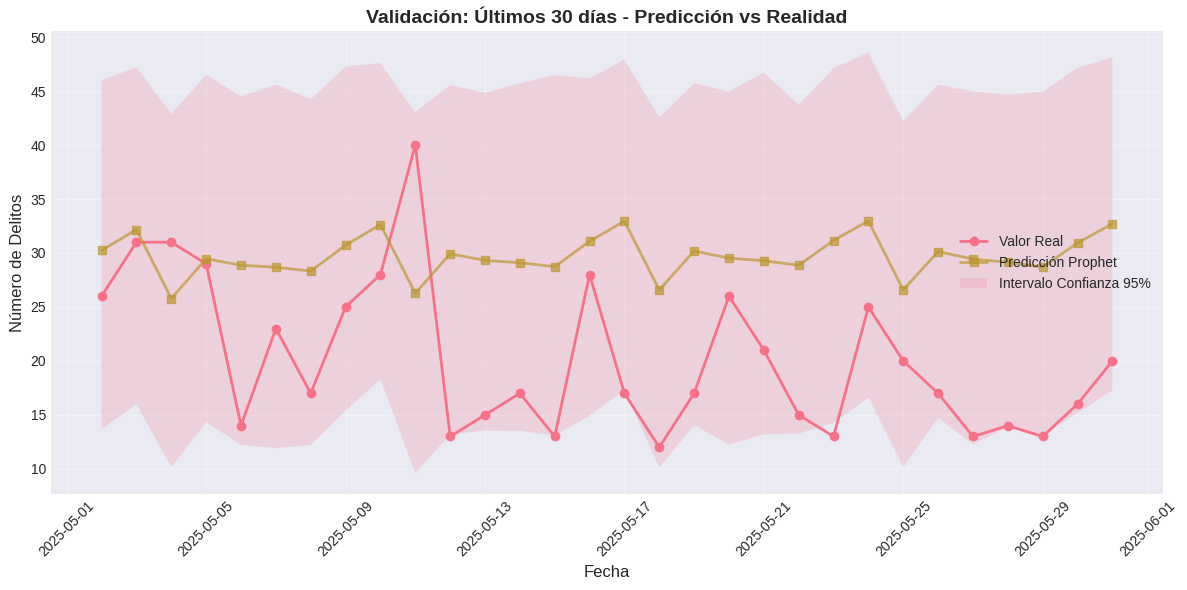


✅ VALIDACIÓN COMPLETADA


In [12]:
# ============================================================================
# VALIDACIÓN TEMPORAL DEL MODELO
# ============================================================================
print("="*80)
print("VALIDACIÓN DEL MODELO PROPHET")
print("="*80)

# Train-Test Split Temporal (últimos 30 días como test)
test_days = 30
train_cutoff = ts_data['ds'].max() - pd.Timedelta(days=test_days)

train_data = ts_data[ts_data['ds'] <= train_cutoff].copy()
test_data = ts_data[ts_data['ds'] > train_cutoff].copy()

print(f"\n📊 División temporal:")
print(f"   Train: {len(train_data):,} días (hasta {train_cutoff.strftime('%Y-%m-%d')})")
print(f"   Test: {len(test_data):,} días (últimos {test_days} días)")

# Re-entrenar modelo en datos de entrenamiento
print(f"\n🔧 Re-entrenando modelo en datos de train...")
model_val = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95,
    seasonality_mode='multiplicative'
)
model_val.add_country_holidays(country_name='CO')
model_val.fit(train_data)

# Predecir en periodo de test
future_val = model_val.make_future_dataframe(periods=test_days, freq='D')
forecast_val = model_val.predict(future_val)

# Extraer predicciones para el periodo de test
forecast_test = forecast_val.tail(test_days).copy()
forecast_test = forecast_test.merge(test_data[['ds', 'y']], on='ds', how='left')

# Calcular métricas
y_true = forecast_test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 para evitar división por 0
r2 = r2_score(y_true, y_pred)

print(f"\n✅ Modelo validado")
print(f"\n📊 MÉTRICAS DE EVALUACIÓN ({test_days} días):")
print(f"   MAE (Mean Absolute Error):  {mae:.2f} delitos/día")
print(f"   RMSE (Root Mean Squared Error): {rmse:.2f} delitos/día")
print(f"   MAPE (Mean Absolute % Error): {mape:.2f}%")
print(f"   R² (Coeficiente determinación): {r2:.4f}")

print(f"\n📈 Interpretación:")
print(f"   • En promedio, el modelo se equivoca por ±{mae:.1f} delitos al predecir un día")
print(f"   • El modelo explica el {r2*100:.1f}% de la variabilidad en los delitos diarios")

# Visualizar predicción vs realidad
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

ax.plot(forecast_test['ds'], y_true, 'o-', label='Valor Real', linewidth=2, markersize=6)
ax.plot(forecast_test['ds'], y_pred, 's-', label='Predicción Prophet', linewidth=2, markersize=6, alpha=0.7)
ax.fill_between(forecast_test['ds'], 
                 forecast_test['yhat_lower'], 
                 forecast_test['yhat_upper'], 
                 alpha=0.2, 
                 label='Intervalo Confianza 95%')

ax.set_title(f'Validación: Últimos {test_days} días - Predicción vs Realidad', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Número de Delitos', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ VALIDACIÓN COMPLETADA")
print(f"{'='*80}")


---

# FASE 3: MÓDULO ESPACIAL - CLUSTERING Y MAPAS DE CALOR

---

## 7. Preparación de Datos Geográficos <a id='7-prep-espacial'></a>

Usaremos las coordenadas del dataset `info_delictiva_bucaramanga` para identificar hotspots criminales.

MÓDULO ESPACIAL: PREPARACIÓN DE DATOS GEOGRÁFICOS

📍 Procesando coordenadas de delitos...
   Total de registros: 135,076
   Coordenadas válidas: 127,755 (94.6%)
   Coordenadas descartadas: 7,321

📊 Estadísticas de coordenadas válidas:
   Latitud  - Min: 7.0026 | Max: 7.2392 | Media: 7.1238
   Longitud - Min: -73.1761 | Max: -73.0547 | Media: -73.1241


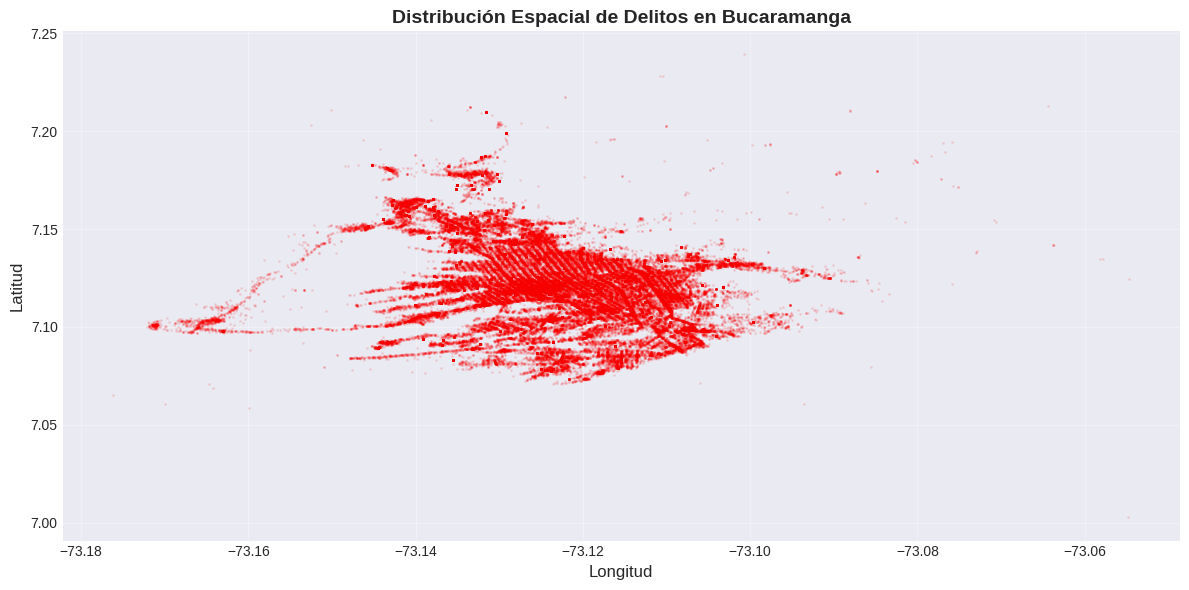

✅ DATOS GEOGRÁFICOS PREPARADOS



In [13]:
# ============================================================================
# MÓDULO ESPACIAL: PREPARACIÓN DE COORDENADAS
# ============================================================================
print("="*80)
print("MÓDULO ESPACIAL: PREPARACIÓN DE DATOS GEOGRÁFICOS")
print("="*80)

# Cargar y limpiar coordenadas
print("\n📍 Procesando coordenadas de delitos...")

# Convertir coordenadas a float
# Usar datos procesados de info_delictiva_bucaramanga
df_info = datasets['info_delictiva_bucaramanga'].copy()

# Extraer coordenadas geográficas (si existen en el dataset)
if 'latitud' in df_info.columns and 'longitud' in df_info.columns:
    df_geo = df_info[['latitud', 'longitud', 'barrios_hecho']].copy()
else:
    # Si no hay coordenadas, usar delitos_bucaramanga
    df_geo = datasets['delitos_bucaramanga'][['latitud', 'longitud', 'barrios_hecho']].copy()

# Convertir a numérico
df_geo['latitud'] = pd.to_numeric(df_geo['latitud'], errors='coerce')
df_geo['longitud'] = pd.to_numeric(df_geo['longitud'], errors='coerce')

print(f"   Total de registros: {len(df_geo):,}")

# Filtrar coordenadas válidas para Bucaramanga
# Bucaramanga: Lat 7.0-7.3°N, Lon -73.5 a -73.0°W
mask_valid = (
    (df_geo['latitud'] >= 7.0) & (df_geo['latitud'] <= 7.3) &
    (df_geo['longitud'] >= -73.5) & (df_geo['longitud'] <= -73.0)
)

df_geo_valid = df_geo[mask_valid].copy()
coords = df_geo_valid[['latitud', 'longitud']].values

print(f"   Coordenadas válidas: {len(coords):,} ({len(coords)/len(df_geo)*100:.1f}%)")
print(f"   Coordenadas descartadas: {len(df_geo) - len(coords):,}")

# Estadísticas de coordenadas
print(f"\n📊 Estadísticas de coordenadas válidas:")
print(f"   Latitud  - Min: {coords[:, 0].min():.4f} | Max: {coords[:, 0].max():.4f} | Media: {coords[:, 0].mean():.4f}")
print(f"   Longitud - Min: {coords[:, 1].min():.4f} | Max: {coords[:, 1].max():.4f} | Media: {coords[:, 1].mean():.4f}")

# Visualización rápida de puntos
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)

ax.scatter(coords[:, 1], coords[:, 0], alpha=0.1, s=1, c='red')
ax.set_title('Distribución Espacial de Delitos en Bucaramanga', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ DATOS GEOGRÁFICOS PREPARADOS")

print(f"\n{'='*80}")

In [14]:
# Superponer datos de delitos con el mapa de barrios de Bucaramanga usando GeoJSON
import geopandas as gpd
import pandas as pd
import plotly.express as px
import requests
from shapely.geometry import Point


barrios_url = "https://vmarcgis01.bucaramanga.gov.co/waserver/rest/services/LIMITES_POLITICOS/Barrios/MapServer/0/query?where=1=1&outFields=*&f=geojson"
response = requests.get(barrios_url)
with open("barrios_bucaramanga.geojson", "wb") as f:
    f.write(response.content)

gdf_barrios = gpd.read_file("barrios_bucaramanga.geojson")

# Verifica columnas
if 'latitud' in df_geo_valid.columns and 'longitud' in df_geo_valid.columns:
    df_geo_valid['geometry'] = df_geo_valid.apply(lambda row: Point(row['longitud'], row['latitud']), axis=1)
    gdf_delitos = gpd.GeoDataFrame(df_geo_valid, geometry='geometry', crs='EPSG:4326')
    # Join espacial
    gdf_delitos_barrio = gpd.sjoin(gdf_delitos, gdf_barrios, how='left', predicate='within')
    
# Visualiza los delitos sobre el mapa de barrios
fig = px.scatter_mapbox(gdf_delitos_barrio, lat=gdf_delitos_barrio.geometry.y, lon=gdf_delitos_barrio.geometry.x,
                        color='NOMBRE_BAR',
                        mapbox_style="carto-positron",
                        zoom=12,
                        title="Delitos asociados a barrios de Bucaramanga")

fig.update_layout(mapbox_layers=[{
    "source": gdf_barrios.__geo_interface__,
    "type": "line",
    "color": "blue",
    "opacity": 0.5
}])

fig.show()

## 8. Clustering con DBSCAN <a id='8-dbscan'></a>

DBSCAN (Density-Based Spatial Clustering) identifica automáticamente zonas de alta densidad delictiva (hotspots) sin necesidad de especificar el número de clusters.

In [15]:
# ============================================================================
# CLUSTERING DBSCAN
# ============================================================================
print("="*80)
print("CLUSTERING DBSCAN: IDENTIFICACIÓN DE HOTSPOTS")
print("="*80)

# Normalizar coordenadas para DBSCAN
print("\n🔧 Normalizando coordenadas...")
scaler_coords = StandardScaler()
coords_scaled = scaler_coords.fit_transform(coords)

print(f"✅ Coordenadas normalizadas: {coords_scaled.shape}")

# Configurar y entrenar DBSCAN
print("\n🔧 Configurando DBSCAN...")

eps_m = 250
earth_m = 6371000.0
eps_rad = eps_m / earth_m  # ≈ 3.9e-5
min_samples = 4

print(f"   eps (radio de vecindad): {eps_rad}")
print(f"   min_samples (mínimo de delitos): {min_samples}")

dbscan = DBSCAN(
    eps=eps_rad,           # Radio de vecindad (ajustable)
    min_samples=min_samples,     # Mínimo de puntos para formar cluster
    metric='haversine'  # Distancia euclidiana en espacio normalizado
)

print("\n🚀 Ejecutando DBSCAN...")
clusters = dbscan.fit_predict(coords_scaled)

# Análisis de clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
n_clustered = len(clusters) - n_noise

print(f"\n✅ Clustering completado")
print(f"\n📊 RESULTADOS DEL CLUSTERING:")
print(f"   Hotspots identificados: {n_clusters}")
print(f"   Delitos en hotspots: {n_clustered:,} ({n_clustered/len(clusters)*100:.1f}%)")
print(f"   Delitos aislados (ruido): {n_noise:,} ({n_noise/len(clusters)*100:.1f}%)")

# stats por cluster y centroids (en grados)
hotspots_info = []
for cid in sorted(set(clusters)):
    if cid == -1:
        continue
    mask = (clusters == cid)
    pts = coords[mask]
    centroid_lat = pts[:,0].mean()
    centroid_lon = pts[:,1].mean()
    n_pts = pts.shape[0]
    hotspots_info.append((cid, centroid_lat, centroid_lon, n_pts))

hotspots_df = pd.DataFrame(hotspots_info, columns=['Hotspot_ID','Latitud','Longitud','N_Delitos'])
hotspots_df = hotspots_df.sort_values('N_Delitos', ascending=False).reset_index(drop=True)

# prioridad basada en percentiles (más robusto que umbrales fijos)
p25, p50, p75 = hotspots_df['N_Delitos'].quantile([0.25,0.5,0.75]).values
def prioridad_from_n(n):
    if n >= p75: return 'MUY ALTA'
    if n >= p50: return 'ALTA'
    if n >= p25: return 'MEDIA'
    return 'BAJA'
hotspots_df['Prioridad'] = hotspots_df['N_Delitos'].apply(prioridad_from_n)

print(f"\n📋 TOP HOTSPOTS IDENTIFICADOS:\n")
display(hotspots_df.head(20))

print(f"\n{'='*80}")
print("✅ HOTSPOTS IDENTIFICADOS")
print(f"{'='*80}")


CLUSTERING DBSCAN: IDENTIFICACIÓN DE HOTSPOTS

🔧 Normalizando coordenadas...
✅ Coordenadas normalizadas: (127755, 2)

🔧 Configurando DBSCAN...
   eps (radio de vecindad): 3.924030764401193e-05
   min_samples (mínimo de delitos): 4

🚀 Ejecutando DBSCAN...

✅ Clustering completado

📊 RESULTADOS DEL CLUSTERING:
   Hotspots identificados: 594
   Delitos en hotspots: 41,420 (32.4%)
   Delitos aislados (ruido): 86,335 (67.6%)

✅ Clustering completado

📊 RESULTADOS DEL CLUSTERING:
   Hotspots identificados: 594
   Delitos en hotspots: 41,420 (32.4%)
   Delitos aislados (ruido): 86,335 (67.6%)

📋 TOP HOTSPOTS IDENTIFICADOS:


📋 TOP HOTSPOTS IDENTIFICADOS:



,Hotspot_ID,Latitud,Longitud,N_Delitos,Prioridad
0,13,7.178046,-73.130224,1799,MUY ALTA
1,0,7.170557,-73.135108,1375,MUY ALTA
2,11,7.144371,-73.128085,1162,MUY ALTA
3,22,7.164624,-73.139141,1073,MUY ALTA
4,1,7.120645,-73.126050,1004,MUY ALTA
5,28,7.138931,-73.120236,842,MUY ALTA
6,76,7.121749,-73.118304,804,MUY ALTA
7,54,7.134521,-73.115880,768,MUY ALTA
8,18,7.148104,-73.126390,761,MUY ALTA
9,135,7.121843,-73.139995,703,MUY ALTA



✅ HOTSPOTS IDENTIFICADOS


In [16]:
# Índices de calidad para DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

if 'dbscan' in globals() and 'coords' in globals():
    labels = dbscan.labels_
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        sil_score = silhouette_score(coords[mask], labels[mask])
        db_score = davies_bouldin_score(coords[mask], labels[mask])
        print(f"Silhouette Score: {sil_score:.3f}")
        print(f"Davies-Bouldin Index: {db_score:.3f}")
    else:
        print("No hay suficientes clusters para calcular los índices de calidad.")
else:
    print('Variables dbscan y/o coords no están disponibles.')

Silhouette Score: 1.000
Davies-Bouldin Index: 0.001


## Evaluación de DBSCAN: Validación visual e índices de calidad
En esta sección se realiza una validación visual de los clusters generados por DBSCAN y se calculan índices de calidad como el Silhouette Score y el Davies-Bouldin Index para evaluar el desempeño del modelo.

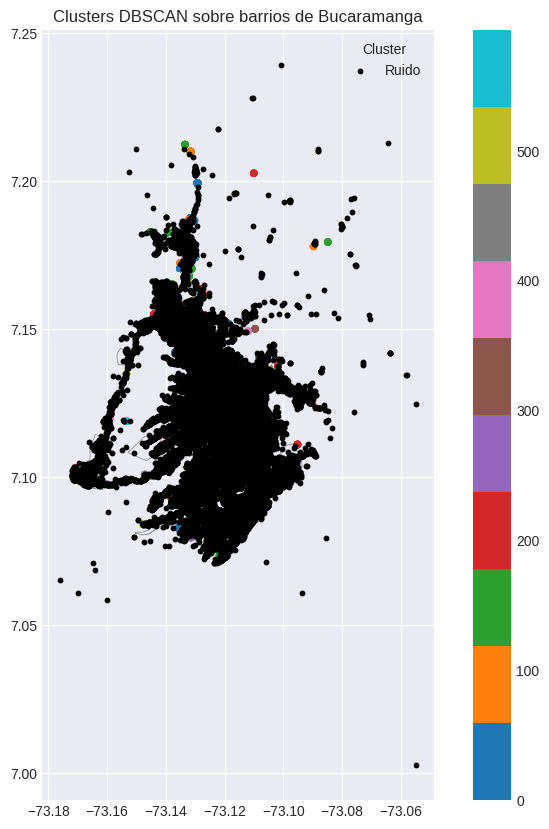

In [17]:
# Validación visual de clusters DBSCAN sobre el mapa de barrios de Bucaramanga
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar barrios
if 'gdf_barrios' in globals():
    gdf_barrios.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5)
else:
    gdf_barrios = gpd.read_file('barrios_bucaramanga.geojson')
    gdf_barrios.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5)

# Dibujar clusters
if 'gdf_delitos' in globals() and 'dbscan' in globals():
    clusters = dbscan.labels_
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    cmap = ListedColormap(plt.cm.get_cmap('tab10').colors[:n_clusters])
    gdf_delitos['cluster'] = clusters
    gdf_delitos[gdf_delitos['cluster'] != -1].plot(ax=ax, column='cluster', cmap=cmap, markersize=20, legend=True)
    gdf_delitos[gdf_delitos['cluster'] == -1].plot(ax=ax, color='black', markersize=10, label='Ruido')
    plt.legend(title='Cluster', loc='upper right')
    plt.title('Clusters DBSCAN sobre barrios de Bucaramanga')
else:
    print('Variables gdf_delitos y/o dbscan no están disponibles.')
plt.show()

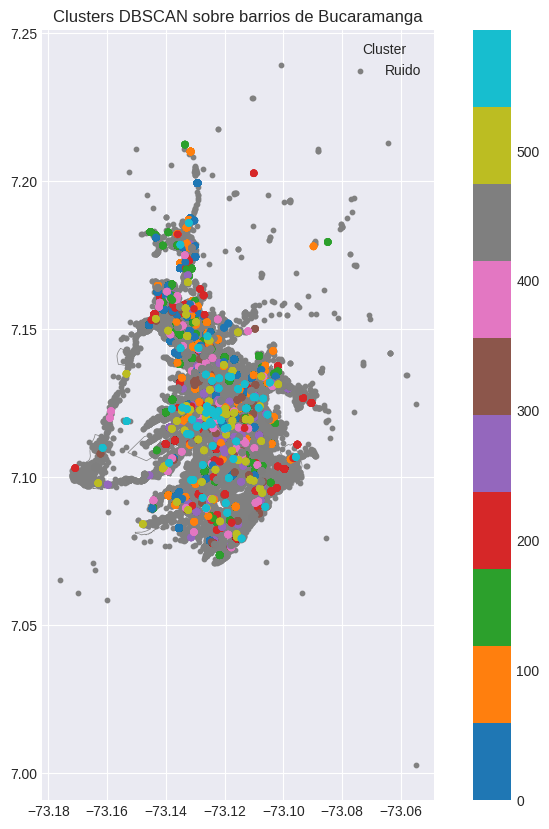

In [18]:
# Validación visual de clusters DBSCAN sobre el mapa de barrios de Bucaramanga
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar barrios
if 'gdf_barrios' in globals():
    gdf_barrios.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5)
else:
    gdf_barrios = gpd.read_file('barrios_bucaramanga.geojson')
    gdf_barrios.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5)

# Dibujar clusters
if 'gdf_delitos' in globals() and 'dbscan' in globals():
    clusters = dbscan.labels_
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    cmap = ListedColormap(plt.cm.get_cmap('tab10').colors[:n_clusters])
    gdf_delitos['cluster'] = clusters
    gdf_delitos[gdf_delitos['cluster'] == -1].plot(ax=ax, color='gray', markersize=10, label='Ruido')
    gdf_delitos[gdf_delitos['cluster'] != -1].plot(ax=ax, column='cluster', cmap=cmap, markersize=20, legend=True)
    plt.legend(title='Cluster', loc='upper right')
    plt.title('Clusters DBSCAN sobre barrios de Bucaramanga')
else:
    print('Variables gdf_delitos y/o dbscan no están disponibles.')
plt.show()

## 9. Mapas de Calor con KDE <a id='9-kde'></a>

Kernel Density Estimation (KDE) genera mapas de calor probabilísticos que muestran la densidad de criminalidad en cada punto del espacio.

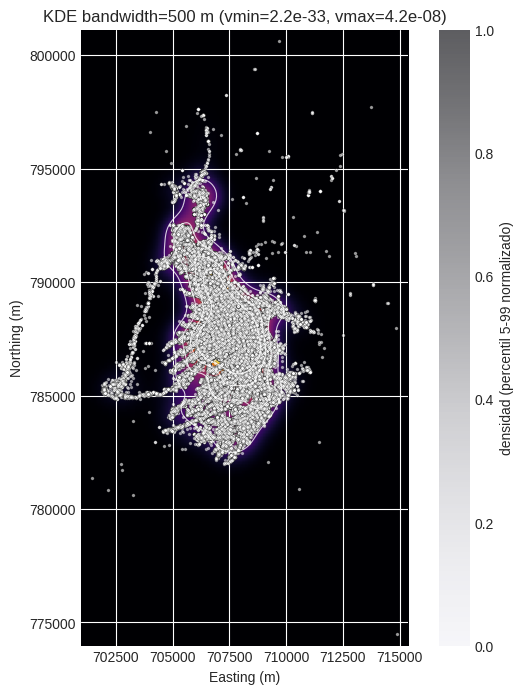

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from pyproj import CRS, Transformer

# coords: array Nx2 con (lat, lon) en grados 
coords = np.array(coords) # asegúrate: shape (N,2) [lat, lon] 

# 1) Reproyectar WGS84 -> UTM zona adecuada para Bucaramanga (ej. EPSG:32618) 
transformer = Transformer.from_crs("epsg:4326", "epsg:32618", always_xy=True) # pyproj usa (lon, lat) entrada 
xs, ys = transformer.transform(coords[:,1], coords[:,0]) 
coords_utm = np.column_stack((xs, ys)) # shape (N,2) en metros 

# 2) Crear grilla en metros que cubra tus datos (en vez de lat/lon duro) 
pad = 500 # m de margen alrededor de los puntos 
xmin, ymin = coords_utm.min(axis=0) - pad 
xmax, ymax = coords_utm.max(axis=0) + pad 

grid_res = 200 # 200x200 píxeles (ajusta) 
xv = np.linspace(xmin, xmax, grid_res) 
yv = np.linspace(ymin, ymax, grid_res) 
xx, yy = np.meshgrid(xv, yv) 
grid_coords = np.column_stack([xx.ravel(), yy.ravel()])

bandwidths = [500]   # probar varios
grid_res = 300

kde_model = None

for bw in bandwidths:
    kde = KernelDensity(bandwidth=bw, kernel='gaussian')
    kde.fit(coords_utm)
    log_dens = kde.score_samples(grid_coords)
    dens = np.exp(log_dens)

    # Escalado por percentil para aumentar contraste (robusto frente a picos extremos)
    vmin = np.percentile(dens, 5)
    vmax = np.percentile(dens, 99)
    dens_clip = np.clip(dens, vmin, vmax)
    dens_norm = (dens_clip - vmin) / (vmax - vmin)

    Z = dens_norm.reshape(xx.shape)

    if bw == 500:
        kde_model = kde  # guardar modelo final

    plt.figure(figsize=(8,8))
    plt.imshow(np.flipud(Z),
               extent=(xmin, xmax, ymin, ymax),
               aspect='equal',
               cmap='inferno')   # prueba 'inferno' o 'hot' para mayor legibilidad
    # contornos para ver bordes de hotspots
    cs = plt.contour(xx, yy, Z, levels=[0.2,0.4,0.6,0.8], colors='white', linewidths=0.8, alpha=0.8)
    plt.scatter(coords_utm[:,0], coords_utm[:,1], s=6, c='white', alpha=0.6, edgecolor='k', linewidth=0.2)
    plt.title(f'KDE bandwidth={bw} m (vmin={vmin:.1e}, vmax={vmax:.1e})')
    plt.colorbar(label='densidad (percentil 5-99 normalizado)')
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    plt.show()


---

# FASE 4: MÓDULO DE RIESGO - CLASIFICACIÓN CON XGBOOST

---

## 10. Feature Engineering para Módulo de Riesgo <a id='10-prep-riesgo'></a>

Combinaremos features temporales, espaciales y contextuales para entrenar el modelo XGBoost.

In [20]:
import re
import pandas as pd
import numpy as np
from unidecode import unidecode  # pip install Unidecode
from rapidfuzz import process, fuzz

# datasets originales
df_info = datasets['info_delictiva_bucaramanga'].copy()
df_del  = datasets['delitos_bucaramanga'].copy()

# ---------------------------------------------------------------------
# 1) Reconstruir fecha_hecho en df_del a partir de ano, mes, dia
# ---------------------------------------------------------------------
df_del['ano'] = pd.to_numeric(df_del['ano'], errors='coerce').astype('Int64')
df_del['dia'] = pd.to_numeric(df_del['dia'], errors='coerce').astype('Int64')
df_del['mes_raw'] = df_del['mes'].astype(str)

def norm_month_text(s):
    s = str(s).lower().strip()
    s = unidecode(s)
    return s

df_del['mes_norm'] = df_del['mes_raw'].apply(norm_month_text)

df_del['mes_num'] = df_del['mes_norm'].str.extract(r'^\s*0*([1-9]|1[0-2])')[0].astype(float)

month_map = {
    'enero':1, 'febrero':2, 'marzo':3, 'abril':4, 'mayo':5, 'junio':6,
    'julio':7, 'agosto':8, 'septiembre':9, 'setiembre':9, 'octubre':10, 'noviembre':11, 'diciembre':12,
    'ene':1, 'feb':2, 'mar':3, 'abr':4, 'may':5, 'jun':6, 'jul':7, 'ago':8, 'sep':9, 'oct':10, 'nov':11, 'dic':12
}

def extract_month_name(s):
    if pd.isna(s) or s.strip()=='':
        return np.nan
    s2 = re.sub(r'^\s*\d+\.*\s*', '', s).strip()
    token = s2.split()[0] if len(s2.split())>0 else s2
    return token

df_del['mes_name'] = df_del['mes_norm'].apply(extract_month_name)
df_del['mes_from_name'] = df_del['mes_name'].map(month_map)
df_del['mes_final'] = df_del['mes_num'].fillna(df_del['mes_from_name']).astype('Float64')

df_del['fecha_hecho'] = pd.to_datetime(
    dict(year=df_del['ano'].astype('Int64'),
         month=df_del['mes_final'].astype('Int64'),
         day=df_del['dia'].astype('Int64')),
    errors='coerce'
)

df_del['fecha'] = df_del['fecha_hecho'].dt.floor('D')

n_invalid_dates = df_del['fecha_hecho'].isna().sum()
total = len(df_del)
print(f"Fechas inválidas en df_del: {n_invalid_dates} / {total} ({n_invalid_dates/total:.1%})")

if n_invalid_dates > 0:
    print(df_del.loc[df_del['fecha_hecho'].isna(),
                     ['ano','mes','dia','mes_raw','mes_norm','mes_name']].head(10))

# ---------------------------------------------------------------------
# 2) Normalizacion texto general
# ---------------------------------------------------------------------
def norm_text(s):
    if pd.isna(s):
        return ''
    s = str(s).lower().strip()
    s = unidecode(s)
    s = re.sub(r'\s+', ' ', s)
    return s

text_cols = ['barrios_hecho', 'conducta', 'armas_medios']

for col in text_cols:
    if col in df_del.columns:
        df_del[col + '_norm'] = df_del[col].astype(str).apply(norm_text)
    if col in df_info.columns:
        df_info[col + '_norm'] = df_info[col].astype(str).apply(norm_text)

df_info['fecha_hecho'] = pd.to_datetime(df_info['fecha_hecho'], errors='coerce')
df_info = df_info[df_info['fecha_hecho'].notna()].copy()
df_info['fecha'] = df_info['fecha_hecho'].dt.floor('D')

# ---------------------------------------------------------------------
# **NUEVO BLOQUE** — Matching entre barrios
# ---------------------------------------------------------------------

# Normalizar aún más fuerte para barrios
def norm_barrio_strong(s):
    if pd.isna(s): return ""
    s = s.upper()
    s = unidecode(s)
    for ch in [",", ".", "-", "(", ")", ";", ":", "/", "'"]:
        s = s.replace(ch, " ")
    s = " ".join(s.split())
    return s.strip()

df_del["barrio_strong"]  = df_del["barrios_hecho_norm"].apply(norm_barrio_strong)
df_info["barrio_strong"] = df_info["barrios_hecho_norm"].apply(norm_barrio_strong)

# Diccionario manual
manual_map = {
    "ANTONIA SANTOS SUR": "ANTONIA SANTOS",
    "ANTONIA SANTOS CENTRO": "ANTONIA SANTOS",
    "LA UNIVERSIDAD": "UNIVERSIDAD",
    "UNIVERSIDAD": "UNIVERSIDAD",
    "PORTON DEL TEJAR": "EL TEJAR",
    "TEJAR NORTE SECTOR I": "EL TEJAR",
    "TEJAR NORTE SECTOR I": "EL TEJAR",
    "SANTA MONICA DEL TEJAR": "EL TEJAR",
    "BOLIVAR": "BOLIVAR",
    "COLORADOS": "COLORADOS"
}

def apply_manual(s):
    return manual_map.get(s, s)

df_del["barrio_strong"]  = df_del["barrio_strong"].apply(apply_manual)
df_info["barrio_strong"] = df_info["barrio_strong"].apply(apply_manual)

# Fuzzy matching
choices = df_info["barrio_strong"].unique().tolist()

def fuzzy_match(value, choices, th=85):
    if not value: return None
    match, score, _ = process.extractOne(value, choices, scorer=fuzz.token_sort_ratio)
    return match if score >= th else None

df_del["barrio_fuzzy"] = df_del["barrio_strong"].apply(lambda x: fuzzy_match(x, choices))
df_del["barrio_match"] = df_del["barrio_fuzzy"].fillna(df_del["barrio_strong"])

# Sustituimos la columna que realmente se usa para el merge
df_del["barrios_hecho_norm"]  = df_del["barrio_match"]
df_info["barrios_hecho_norm"] = df_info["barrio_strong"]

# ---------------------------------------------------------------------
# 3) Crear merge_key
# ---------------------------------------------------------------------
possible_keys = ['fecha', 'barrios_hecho_norm', 'conducta_norm', 'armas_medios_norm']

merge_fields = [c for c in possible_keys if (c in df_del.columns) and (c in df_info.columns)]
print("Campos disponibles para merge_key:", merge_fields)

if 'fecha' in df_del.columns and 'fecha' in df_info.columns and 'fecha' not in merge_fields:
    merge_fields = ['fecha']

def make_key_from_row(row, fields):
    vals = []
    for f in fields:
        v = row.get(f)
        vals.append("" if pd.isna(v) else str(v))
    return "|".join(vals)

if len(merge_fields)==0:
    raise ValueError("No hay columnas comunes para crear llave de merge.")

df_del['merge_key']  = df_del.apply(lambda r: make_key_from_row(r, merge_fields), axis=1)
df_info['merge_key'] = df_info.apply(lambda r: make_key_from_row(r, merge_fields), axis=1)

# ---------------------------------------------------------------------
# 4) Agregar lat/lon y zona
# ---------------------------------------------------------------------
agg = df_del.groupby('merge_key').agg({
    'latitud': 'median',
    'longitud': 'median',
    **({'zona': (lambda x: x.mode().iat[0] if len(x.mode())>0 else np.nan)} if 'zona' in df_del.columns else {})
}).reset_index()

agg = agg.rename(columns={'latitud':'lat_med','longitud':'lon_med','zona':'zona_mode'}
                 if 'zona' in agg.columns else
                 {'latitud':'lat_med','longitud':'lon_med'})

df_merge = df_info.merge(agg, on='merge_key', how='left')
df_merge['matched_exact'] = df_merge['lat_med'].notna()

print("Exact matches tras merge:", df_merge['matched_exact'].mean())

# ---------------------------------------------------------------------
# 5) Imputaciones por barrio
# ---------------------------------------------------------------------
if 'barrios_hecho_norm' in df_del.columns:
    barrio_centroids = df_del.groupby('barrios_hecho_norm').agg(
        lat_centroid=('latitud','median'),
        lon_centroid=('longitud','median')
    ).reset_index().set_index('barrios_hecho_norm')

    mask_no_coords = df_merge['lat_med'].isna()

    if mask_no_coords.any() and 'barrios_hecho_norm' in df_merge.columns:
        def impute_coords_by_barrio(row):
            b = row.get('barrios_hecho_norm','')
            if pd.isna(row['lat_med']) and b in barrio_centroids.index:
                return pd.Series([barrio_centroids.at[b,'lat_centroid'],
                                  barrio_centroids.at[b,'lon_centroid']])
            return pd.Series([row['lat_med'], row['lon_med']])

        df_merge[['lat_med','lon_med']] = df_merge.apply(impute_coords_by_barrio, axis=1)
        df_merge['imputed_barrio'] = df_merge['lat_med'].notna() & (~df_merge['matched_exact'])
    else:
        df_merge['imputed_barrio'] = False
else:
    df_merge['imputed_barrio'] = False

df_merge = df_merge.rename(columns={'lat_med':'latitud','lon_med':'longitud'})
df_merge['coords_available'] = df_merge['latitud'].notna() & df_merge['longitud'].notna()

print("After imputation:", df_merge['coords_available'].mean())

# ---------------------------------------------------------------------
# 6) Resultado final
# ---------------------------------------------------------------------
n_missing = df_merge['coords_available'].isna().sum() + (~df_merge['coords_available']).sum()
print("Registros sin coords:", n_missing)

df_merge.to_parquet('df_merged_with_coords.parquet')


Fechas inválidas en df_del: 0 / 135076 (0.0%)
Campos disponibles para merge_key: ['fecha', 'barrios_hecho_norm', 'armas_medios_norm']
Campos disponibles para merge_key: ['fecha', 'barrios_hecho_norm', 'armas_medios_norm']
Exact matches tras merge: 0.36350985313486245
Exact matches tras merge: 0.36350985313486245
After imputation: 0.9598585190891545
Registros sin coords: 4846
After imputation: 0.9598585190891545
Registros sin coords: 4846


In [21]:
# crea columna merge_source
df_merge['merge_source'] = np.where(df_merge['matched_exact'], 'exact', 
                           np.where(df_merge.get('matched_fuzzy', False), 'fuzzy',
                                    np.where(df_merge.get('imputed_barrio', False), 'imputed_barrio', 'none')))

# resumen
print(df_merge['merge_source'].value_counts(dropna=False))
print("\nPorcentaje:")
print((df_merge['merge_source'].value_counts(normalize=True)*100).round(2))


merge_source
imputed_barrio    71993
exact             43884
none               4846
Name: count, dtype: int64

Porcentaje:
merge_source
imputed_barrio    59.63
exact             36.35
none               4.01
Name: proportion, dtype: float64


Inspección manual — muestreo para validar calidad

In [22]:
def sample_and_show(df, source, n=30):
    s = df[df['merge_source']==source].sample(min(n, len(df[df['merge_source']==source])), random_state=42)
    display(s.head(n)[['merge_key','barrios_hecho','barrios_hecho_norm','armas_medios','armas_medios_norm','fecha','latitud','longitud']])

for src in ['exact','fuzzy','imputed_barrio','none']:
    print(f"\n--- Muestra {src} ---")
    sample_and_show(df_merge, src, n=15)



--- Muestra exact ---


,merge_key,barrios_hecho,barrios_hecho_norm,armas_medios,armas_medios_norm,fecha,latitud,longitud
67222,2021-08-28 00:00:00|LA CONCORDIA|sin empleo de...,LA CONCORDIA,LA CONCORDIA,SIN EMPLEO DE ARMAS,sin empleo de armas,2021-08-28,7.114324,-73.122757
59945,2021-03-02 00:00:00|PROVENZA|sin empleo de armas,PROVENZA,PROVENZA,SIN EMPLEO DE ARMAS,sin empleo de armas,2021-03-02,7.087507,-73.108839
5911,2016-07-16 00:00:00|GARCIA ROVIRA|sin empleo d...,GARCIA ROVIRA,GARCIA ROVIRA,SIN EMPLEO DE ARMAS,sin empleo de armas,2016-07-16,7.117190,-73.128867
42079,2019-08-20 00:00:00|CENTRO|sin empleo de armas,CENTRO,CENTRO,SIN EMPLEO DE ARMAS,sin empleo de armas,2019-08-20,7.122358,-73.126373
7674,2016-09-16 00:00:00|OTRAS|contundentes,OTRAS,OTRAS,CONTUNDENTES,contundentes,2016-09-16,7.116404,-73.129294
34775,2019-01-17 00:00:00|CIUDADELA REAL DE MINAS|si...,CIUDADELA REAL DE MINAS,CIUDADELA REAL DE MINAS,SIN EMPLEO DE ARMAS,sin empleo de armas,2019-01-17,7.103600,-73.124363
66136,2021-08-03 00:00:00|ALARCON|arma blanca / cort...,ALARCON,ALARCON,ARMA BLANCA / CORTOPUNZANTE,arma blanca / cortopunzante,2021-08-03,7.127376,-73.121673
38354,2019-04-30 00:00:00|MUTIS|sin empleo de armas,MUTIS,MUTIS,SIN EMPLEO DE ARMAS,sin empleo de armas,2019-04-30,7.097076,-73.131384
36484,2019-03-08 00:00:00|CAMPO HERMOSO|contundentes,CAMPO HERMOSO,CAMPO HERMOSO,CONTUNDENTES,contundentes,2019-03-08,7.108582,-73.136603
17540,2017-08-17 00:00:00|SAN FRANCISCO|sin empleo d...,SAN FRANCISCO,SAN FRANCISCO,SIN EMPLEO DE ARMAS,sin empleo de armas,2017-08-17,7.130005,-73.122130



--- Muestra fuzzy ---


,merge_key,barrios_hecho,barrios_hecho_norm,armas_medios,armas_medios_norm,fecha,latitud,longitud



--- Muestra imputed_barrio ---


,merge_key,barrios_hecho,barrios_hecho_norm,armas_medios,armas_medios_norm,fecha,latitud,longitud
32775,2018-11-19 00:00:00|CENTRO|contundentes,CENTRO,CENTRO,CONTUNDENTES,contundentes,2018-11-19,7.120226,-73.126050
100628,2023-10-13 00:00:00|OTRAS|sin empleo de armas,OTRAS,OTRAS,SIN EMPLEO DE ARMAS,sin empleo de armas,2023-10-13,7.121749,-73.125792
84165,2022-09-20 00:00:00|SOTOMAYOR|sin empleo de armas,SOTOMAYOR,SOTOMAYOR,SIN EMPLEO DE ARMAS,sin empleo de armas,2022-09-20,7.116826,-73.115024
32136,2018-10-31 00:00:00|ALARCON|arma blanca / cort...,ALARCON,ALARCON,ARMA BLANCA / CORTOPUNZANTE,arma blanca / cortopunzante,2018-10-31,7.126482,-73.124378
104591,2024-01-24 00:00:00|CENTRO|sin empleo de armas,CENTRO,CENTRO,SIN EMPLEO DE ARMAS,sin empleo de armas,2024-01-24,7.120226,-73.126050
47132,2019-12-31 00:00:00|CENTRO|sin empleo de armas,CENTRO,CENTRO,SIN EMPLEO DE ARMAS,sin empleo de armas,2019-12-31,7.120226,-73.126050
53681,2020-09-01 00:00:00|MUTIS|sin empleo de armas,MUTIS,MUTIS,SIN EMPLEO DE ARMAS,sin empleo de armas,2020-09-01,7.099617,-73.130507
91251,2023-03-04 00:00:00|CAMPO HERMOSO|arma de fuego,CAMPO HERMOSO,CAMPO HERMOSO,ARMA DE FUEGO,arma de fuego,2023-03-04,7.106604,-73.137312
86696,2022-11-15 00:00:00|CABECERA DEL LLANO|sin emp...,CABECERA DEL LLANO,CABECERA DEL LLANO,SIN EMPLEO DE ARMAS,sin empleo de armas,2022-11-15,7.116853,-73.110022
90275,2023-02-10 00:00:00|CIUDADELA REAL DE MINAS|si...,CIUDADELA REAL DE MINAS,CIUDADELA REAL DE MINAS,SIN EMPLEO DE ARMAS,sin empleo de armas,2023-02-10,7.104012,-73.124031



--- Muestra none ---


,merge_key,barrios_hecho,barrios_hecho_norm,armas_medios,armas_medios_norm,fecha,latitud,longitud
102850,2023-12-09 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2023-12-09,NaN,NaN
64398,2021-06-22 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2021-06-22,NaN,NaN
42552,2019-09-02 00:00:00|COLORADOS|contundentes,COLORADOS,COLORADOS,CONTUNDENTES,contundentes,2019-09-02,NaN,NaN
112773,2024-09-08 00:00:00|BOLIVAR|sin empleo de armas,BOLIVAR,BOLIVAR,SIN EMPLEO DE ARMAS,sin empleo de armas,2024-09-08,NaN,NaN
59423,2021-02-18 00:00:00|COLORADOS|arma blanca / co...,COLORADOS,COLORADOS,ARMA BLANCA / CORTOPUNZANTE,arma blanca / cortopunzante,2021-02-18,NaN,NaN
42129,2019-08-21 00:00:00|COLORADOS|sin empleo de armas,COLORADOS,COLORADOS,SIN EMPLEO DE ARMAS,sin empleo de armas,2019-08-21,NaN,NaN
72131,2021-12-14 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2021-12-14,NaN,NaN
113896,2024-10-08 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2024-10-08,NaN,NaN
111476,2024-08-04 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2024-08-04,NaN,NaN
106256,2024-03-11 00:00:00|NO DISPONIBLE|sin empleo d...,NO DISPONIBLE,NO DISPONIBLE,SIN EMPLEO DE ARMAS,sin empleo de armas,2024-03-11,NaN,NaN


Distribución de faltantes por barrio (detecta sesgo)

In [23]:
missing_by_barrio = df_merge[df_merge['coords_available']==False].groupby('barrios_hecho_norm').size().rename('n_missing')
total_by_barrio   = df_merge.groupby('barrios_hecho_norm').size().rename('n_total')
report = (total_by_barrio.to_frame().join(missing_by_barrio, how='left').fillna(0))
report['pct_missing'] = (report['n_missing'] / report['n_total'] * 100).round(2)
report = report.sort_values('pct_missing', ascending=False)
display(report.head(20))


,n_total,n_missing,pct_missing
barrios_hecho_norm,,,
BOLIVAR,1213,1213.0,100.0
COLORADOS,1487,1487.0,100.0
NO DISPONIBLE,2146,2146.0,100.0
ANTONIA SANTOS,2498,0.0,0.0
ALARCON,1810,0.0,0.0
CABECERA DEL LLANO,6258,0.0,0.0
CAFE MADRID,2426,0.0,0.0
CENTRO,10123,0.0,0.0
CAMPO HERMOSO,2130,0.0,0.0


In [24]:
# ==========================
# PIPELINE ZONA-DIA -> XGBOOST
# ==========================
import numpy as np
import pandas as pd
from datetime import timedelta
from sklearn.neighbors import KDTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

RANDOM_STATE = 42

# ---------- 0) Pre-req checks ----------
df = df_merge.copy()
# fecha como datetime y fecha_d (solo día)
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')
df = df[df['fecha_hecho'].notna()].copy()
df['fecha'] = df['fecha_hecho'].dt.floor('D')

# zona_id must exist
if 'zona_id' not in df.columns:
    # fallback: build simple grid zone from lat/lon
    df['zona_id'] = (df['latitud'] // 0.01).astype(str) + "_" + (df['longitud'] // 0.01).astype(str)

# ---------- 1) Construir matriz completa zona x fecha ----------
zones = df['zona_id'].unique()
date_min = df['fecha'].min()
date_max = df['fecha'].max()
dates = pd.date_range(date_min, date_max, freq='D')

# MultiIndex full grid
idx = pd.MultiIndex.from_product([zones, dates], names=['zona_id','fecha'])
zone_day = pd.DataFrame(index=idx).reset_index()

# contar delitos por zona-dia
counts = df.groupby(['zona_id','fecha']).size().reset_index(name='count')
zone_day = zone_day.merge(counts, on=['zona_id','fecha'], how='left')
zone_day['count'] = zone_day['count'].fillna(0).astype(int)

# ---------- 2) Features temporales (a nivel zona-dia) ----------
zone_day['dow'] = zone_day['fecha'].dt.dayofweek
zone_day['is_weekend'] = (zone_day['dow'] >= 5).astype(int)
zone_day['month'] = zone_day['fecha'].dt.month
zone_day['year'] = zone_day['fecha'].dt.year
zone_day['week_of_year'] = zone_day['fecha'].dt.isocalendar().week.astype(int)

# ---------- 3) Rolling features (IMPORTANTE: shift(1) para excluir el día actual) ----------
zone_day = zone_day.sort_values(['zona_id','fecha'])
grouped = zone_day.groupby('zona_id')['count']

# lag-1 (delitos del dia anterior)
zone_day['count_lag1'] = grouped.shift(1).fillna(0)

# rolling excluding today: shift then rolling
zone_day['delitos_7d'] = grouped.shift(1).rolling(window=7, min_periods=1).sum().reset_index(level=0, drop=True)
zone_day['delitos_30d'] = grouped.shift(1).rolling(window=30, min_periods=1).sum().reset_index(level=0, drop=True)

# ---------- 4) Target: ¿habrá delito mañana en esta zona? (predictivo) ----------
zone_day['count_next_day'] = grouped.shift(-1).fillna(0).astype(int)
# binary target: 1 if >=1 delito next day (puedes cambiar a threshold>1)
zone_day['target'] = (zone_day['count_next_day'] >= 1).astype(int)

# ---------- 5) Agregar features espaciales estáticas por zona ----------
# por ejemplo centroides de zona desde df original
centroids = df.groupby('zona_id')[['latitud','longitud']].mean().reset_index()
# Eliminar zonas con coordenadas NaN para evitar errores
centroids = centroids.dropna(subset=['latitud', 'longitud'])
zone_day = zone_day.merge(centroids, on='zona_id', how='left')

# Si tienes cluster centroids (resultado DBSCAN original), asigna cluster a zona por KDTree (vectorizado)
# Suponiendo que `clusters` y `coords` existen (coords en lat/lon)
if 'clusters' in globals() and 'coords' in globals():
    import numpy as np
    unique_labels = np.array(clusters)
    # coords assumed shape (N,2) lat,lon
    coords_arr = np.array(coords)
    # crear KDTree en lat/lon y query centroid lat/lon
    tree = KDTree(np.radians(coords_arr))  # opcional usar haversine via radians + custom metric; here naive
    # Warning: if coords are UTM use directly
    _, idxs = tree.query(np.radians(centroids[['latitud','longitud']].values), k=1)
    zone_clusters = pd.DataFrame({
        'zona_id': centroids['zona_id'],
        'zone_cluster_id': unique_labels[idxs.flatten()]
    })
    zone_day = zone_day.merge(zone_clusters, on='zona_id', how='left')
else:
    zone_day['zone_cluster_id'] = -1

# ---------- 6) Categóricas codificadas: merge precomputed encodings if exist ----------
# ejemplo: si df_risk tenía barrios_hecho_encoded mapéalo
if 'barrios_hecho' in df.columns and 'barrios_encoded' in df.columns:
    # crear mapping
    mapping = df[['barrios_hecho','barrios_encoded']].drop_duplicates().set_index('barrios_hecho')['barrios_encoded'].to_dict()
    # zone-level barrio: most common barrio per zona
    zone_barrio = df.groupby('zona_id')['barrios_hecho'].agg(lambda x: x.mode().iat[0] if len(x.mode())>0 else x.iloc[0]).reset_index()
    zone_barrio['barrios_encoded'] = zone_barrio['barrios_hecho'].map(mapping).fillna(-1).astype(int)
    zone_day = zone_day.merge(zone_barrio[['zona_id','barrios_encoded']], on='zona_id', how='left')
else:
    zone_day['barrios_encoded'] = -1

# ---------- 7) Limpiar y seleccionar features para el modelo ----------
# Candidate features (ajusta según columnas disponibles)
feature_cols = [
    'year','month','dow','is_weekend','week_of_year',
    'latitud','longitud',
    'count_lag1','delitos_7d','delitos_30d',
    'zone_cluster_id','barrios_encoded'
]
# keep only those that exist
feature_cols = [c for c in feature_cols if c in zone_day.columns]

df_model = zone_day.dropna(subset=feature_cols + ['target']).copy()

print("Registros (zona-dia):", len(df_model))
print("Distribución target:", df_model['target'].value_counts(normalize=True).to_dict())

# ---------- 8) Temporal train-test split ----------
# usar fecha para split
dates_sorted = sorted(df_model['fecha'].unique())
cutoff_idx = int(len(dates_sorted) * 0.8)
cutoff_date = dates_sorted[cutoff_idx]
train_df = df_model[df_model['fecha'] <= cutoff_date].copy()
test_df = df_model[df_model['fecha'] > cutoff_date].copy()

X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

print("Train days up to:", cutoff_date, " ->", len(train_df), "rows")
print("Test days after:", cutoff_date, " ->", len(test_df), "rows")

# ---------- 9) balance weight safe ----------
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
if pos == 0:
    scale_pos_weight = 1.0
else:
    scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

Registros (zona-dia): 361094
Distribución target: {0: 0.898993059978842, 1: 0.10100694002115793}
Train days up to: 2023-07-14 00:00:00  -> 288959 rows
Test days after: 2023-07-14 00:00:00  -> 72135 rows
scale_pos_weight: 8.57959819652566


## 11. Modelo XGBoost <a id='11-xgboost'></a>

Entrenaremos un clasificador XGBoost para predecir si ocurrirá un delito en una zona-día específica.

In [25]:
# ---------- 10) Entrenar XGBoost con early stopping y eval_set ----------
model_xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    early_stopping_rounds=50,
    colsample_bytree=0.8,
    reg_alpha=1.0,            # Regularización L1
    reg_lambda=1.0,           # Regularización L2
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='aucpr'
)

eval_set = [(X_train, y_train), (X_test, y_test)]
model_xgb.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=50
)

[0]	validation_0-aucpr:0.42173	validation_1-aucpr:0.38366
[50]	validation_0-aucpr:0.72954	validation_1-aucpr:0.78934
[50]	validation_0-aucpr:0.72954	validation_1-aucpr:0.78934
[100]	validation_0-aucpr:0.74476	validation_1-aucpr:0.80192
[100]	validation_0-aucpr:0.74476	validation_1-aucpr:0.80192
[150]	validation_0-aucpr:0.75778	validation_1-aucpr:0.80866
[150]	validation_0-aucpr:0.75778	validation_1-aucpr:0.80866
[200]	validation_0-aucpr:0.76580	validation_1-aucpr:0.81445
[200]	validation_0-aucpr:0.76580	validation_1-aucpr:0.81445
[250]	validation_0-aucpr:0.76957	validation_1-aucpr:0.81815
[250]	validation_0-aucpr:0.76957	validation_1-aucpr:0.81815
[300]	validation_0-aucpr:0.77190	validation_1-aucpr:0.81985
[300]	validation_0-aucpr:0.77190	validation_1-aucpr:0.81985
[350]	validation_0-aucpr:0.77366	validation_1-aucpr:0.82106
[350]	validation_0-aucpr:0.77366	validation_1-aucpr:0.82106
[400]	validation_0-aucpr:0.77517	validation_1-aucpr:0.82192
[400]	validation_0-aucpr:0.77517	validation_

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'aucpr'


### 11.1 Evaluación del Modelo XGBoost

Mejor umbral (F1-score): 0.8675
F1-score máximo: 0.7237

--- Reporte con umbral ajustado ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     65826
           1       0.68      0.78      0.72      6309

    accuracy                           0.95     72135
   macro avg       0.83      0.87      0.85     72135
weighted avg       0.95      0.95      0.95     72135

ROC AUC: 0.9810014000753015
Confusion matrix:
 [[63458  2368]
 [ 1389  4920]]


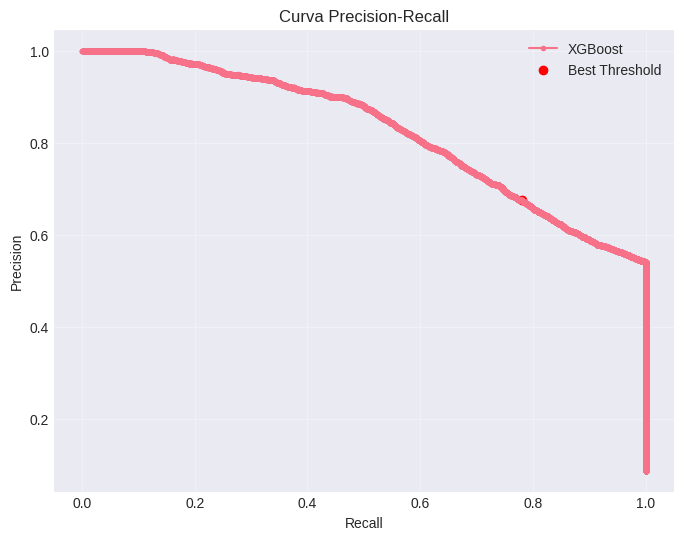

In [26]:
# ---------- 11) Evaluación y Ajuste de Umbral ----------
from sklearn.metrics import precision_recall_curve

# Obtener probabilidades en test
y_proba = model_xgb.predict_proba(X_test)[:,1]

# Calcular curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Buscar el umbral que maximiza F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Mejor umbral (F1-score): {best_threshold:.4f}")
print(f"F1-score máximo: {best_f1:.4f}")

# Aplicar nuevo umbral
y_pred_adjusted = (y_proba >= best_threshold).astype(int)

print("\n--- Reporte con umbral ajustado ---")
print(classification_report(y_test, y_pred_adjusted))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_adjusted))

# Visualizar curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, marker='.', label='XGBoost')
plt.scatter(recalls[best_idx], precisions[best_idx], marker='o', color='red', label='Best Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# ---------- 12) Importancia de features ----------
importances = model_xgb.feature_importances_
for f, imp in sorted(zip(feature_cols, importances), key=lambda x: -x[1]):
    print(f"{f}: {imp:.4f}")

count_lag1: 0.5831
longitud: 0.1842
latitud: 0.1136
zone_cluster_id: 0.0358
year: 0.0169
delitos_30d: 0.0156
month: 0.0155
delitos_7d: 0.0141
week_of_year: 0.0099
is_weekend: 0.0058
dow: 0.0056
barrios_encoded: 0.0000


---

# FASE 5: INTEGRACIÓN Y EXPORTACIÓN

---

## 12. Sistema Ensemble <a id='12-ensemble'></a>

Combinaremos las predicciones de los tres módulos para crear un sistema integrado de evaluación de riesgo.

In [28]:
# ============================================================================
# SISTEMA ENSEMBLE: INTEGRACIÓN DE LOS 3 MÓDULOS
# ============================================================================
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

print("="*80)
print("SISTEMA ENSEMBLE: INTEGRACIÓN DE MÓDULOS")
print("="*80)

# ============================================================================
# 1. FUNCIÓN PRINCIPAL DE PREDICCIÓN ENSEMBLE
# ============================================================================

def predict_risk_ensemble(fecha, latitud, longitud, 
                         model_prophet, kde_model, model_xgb, 
                         feature_cols, scaler_coords=None, transformer=None,
                         density_max=None, density_grid=None,
                         weights=None, verbose=False):
    """
    Predice el riesgo de criminalidad combinando los 3 módulos.
    
    Parameters:
    -----------
    fecha : datetime o str
        Fecha para la predicción (formato: 'YYYY-MM-DD')
    latitud : float
        Latitud de la ubicación (grados decimales)
    longitud : float
        Longitud de la ubicación (grados decimales)
    model_prophet : Prophet
        Modelo temporal entrenado
    kde_model : gaussian_kde
        Modelo KDE entrenado (si es None, score_espacial = 0)
    model_xgb : XGBClassifier
        Modelo XGBoost entrenado
    feature_cols : list
        Lista de nombres de features para XGBoost
    scaler_coords : StandardScaler
        Escalador de coordenadas (opcional, para DBSCAN/features)
    transformer : Transformer
        Transformador de coordenadas (opcional, para KDE UTM)
    density_max : float
        Máximo valor de densidad KDE conocido (para normalización)
    density_grid : ndarray
        Grid de densidad precalculado (alternativa a KDE en vivo)
    weights : dict
        Pesos para el ensemble {'temporal': 0.2, 'espacial': 0.3, 'riesgo': 0.5}
    verbose : bool
        Si True, imprime detalles de la predicción
    
    Returns:
    --------
    dict : Diccionario con scores y predicción final
    """
    
    # Pesos por defecto
    if weights is None:
        weights = {'temporal': 0.2, 'espacial': 0.3, 'riesgo': 0.5}
    
    # Asegurar que fecha es datetime
    if isinstance(fecha, str):
        fecha = pd.Timestamp(fecha)
    
    # ========================
    # MÓDULO 1: TEMPORAL (20%)
    # ========================
    try:
        future_df = pd.DataFrame({'ds': [fecha]})
        
        # --- AGREGAR REGRESORES PARA PROPHET ---
        # 1. Días de la semana (one-hot)
        days = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
        day_idx = fecha.dayofweek
        for i, day_name in enumerate(days):
            future_df[day_name] = 1 if i == day_idx else 0
            
        # 2. Quincenas
        day_num = fecha.day
        future_df['quincena_1'] = 1 if (day_num >= 12 and day_num <= 16) else 0
        future_df['quincena_2'] = 1 if (day_num >= 27 or day_num <= 2) else 0
        
        # 3. Otros efectos de calendario
        future_df['is_weekend'] = 1 if day_idx >= 5 else 0
        future_df['is_month_start'] = 1 if fecha.is_month_start else 0
        future_df['is_month_end'] = 1 if fecha.is_month_end else 0
        future_df['is_holiday_season'] = 1 if fecha.month in [12, 1, 6, 7] else 0
        
        # Predicción
        forecast_temporal = model_prophet.predict(future_df)
        delitos_esperados = float(forecast_temporal['yhat'].values[0])
        
        # Normalizar a [0, 1] usando percentiles robustos
        # Asumiendo máximo típico de ~100 delitos/día
        score_temporal = min(max(delitos_esperados / 100, 0), 1.0)
        
        if verbose:
            print(f"✓ Temporal: {delitos_esperados:.2f} delitos → score {score_temporal:.3f}")
    except Exception as e:
        if verbose:
            print(f"✗ Error en módulo temporal: {e}")
        score_temporal = 0.5
        delitos_esperados = 0.0
    
    # ========================
    # MÓDULO 2: ESPACIAL (30%)
    # ========================
    try:
        # Validar que coordenadas estén dentro de Bucaramanga
        if not (7.0 <= latitud <= 7.3 and -73.5 <= longitud <= -73.0):
            score_espacial = 0.0
            if verbose:
                print(f"⚠ Coordenadas fuera del área: ({latitud:.4f}, {longitud:.4f})")
        elif kde_model is not None:
            # Usar KDE en vivo
            try:
                # Transformar coordenadas si es necesario
                if transformer is not None:
                    # PyProj transformer: (lon, lat) -> (x, y)
                    x, y = transformer.transform(longitud, latitud)
                    coords_input = np.array([[x, y]])
                else:
                    # Asumir lat/lon si no hay transformer
                    coords_input = np.array([[latitud, longitud]])
                
                # Si el modelo es sklearn KernelDensity
                if hasattr(kde_model, 'score_samples'):
                    log_dens = kde_model.score_samples(coords_input)
                    densidad_kde = np.exp(log_dens)[0]
                else:
                    # Si es scipy gaussian_kde
                    densidad_kde = kde_model(coords_input.T)[0]
                
                # Normalizar con density_max conocido
                if density_max is not None and density_max > 0:
                    score_espacial = min(densidad_kde / density_max, 1.0)
                else:
                    # Normalización heurística si no hay max
                    score_espacial = min(densidad_kde / (densidad_kde + 1e-6 + 0.1), 1.0)
                
                if verbose:
                    print(f"✓ Espacial (KDE): densidad {densidad_kde:.3e} → score {score_espacial:.3f}")
            except Exception as e:
                if verbose:
                    print(f"⚠ Error ejecutando KDE: {e}")
                score_espacial = 0.3  # Default si falla KDE
        elif density_grid is not None:
            # Usar grid de densidad precalculado
            score_espacial = 0.3
            if verbose:
                print(f"ℹ Espacial (Grid): usando valor por defecto")
        else:
            score_espacial = 0.3  # Default si no hay modelo KDE
            if verbose:
                print(f"ℹ Espacial: sin modelo KDE, usando default 0.3")
    
    except Exception as e:
        if verbose:
            print(f"✗ Error en módulo espacial: {e}")
        score_espacial = 0.3
    
    # ========================
    # MÓDULO 3: RIESGO (50%)
    # ========================
    try:
        # Preparar features - IMPORTANTE: orden debe coincidir con feature_cols
        features_dict = {
            'year': fecha.year,
            'month': fecha.month,
            'dow': fecha.dayofweek,
            'is_weekend': int(fecha.dayofweek >= 5),
            'week_of_year': fecha.isocalendar()[1],
            'latitud': latitud,
            'longitud': longitud,
            'count_lag1': 0,  # Valor por defecto (sin histórico)
            'delitos_7d': 0,
            'delitos_30d': 0,
            'zone_cluster_id': -1,
            'barrios_encoded': -1
        }
        
        # Construir array de features en orden correcto
        X_input = np.array([[features_dict.get(col, 0) for col in feature_cols]])
        
        # Predicción de probabilidad
        prob_xgb = model_xgb.predict_proba(X_input)[0, 1]
        score_riesgo = float(prob_xgb)
        
        if verbose:
            print(f"✓ Riesgo (XGBoost): probabilidad {score_riesgo:.3f}")
    
    except Exception as e:
        if verbose:
            print(f"✗ Error en módulo riesgo: {e}")
        score_riesgo = 0.5
    
    # ========================
    # ENSEMBLE: VOTACIÓN PONDERADA
    # ========================
    w_temporal = weights.get('temporal', 0.2)
    w_espacial = weights.get('espacial', 0.3)
    w_riesgo = weights.get('riesgo', 0.5)
    
    # Normalizar pesos
    w_total = w_temporal + w_espacial + w_riesgo
    w_temporal /= w_total
    w_espacial /= w_total
    w_riesgo /= w_total
    
    score_final = (w_temporal * score_temporal + 
                   w_espacial * score_espacial + 
                   w_riesgo * score_riesgo)
    
    score_final = min(max(score_final, 0), 1.0)
    
    # ========================
    # CLASIFICACIÓN DE RIESGO
    # ========================
    if score_final > 0.7:
        nivel_riesgo = 'ALTO'
        color_riesgo = '🔴'
    elif score_final > 0.4:
        nivel_riesgo = 'MEDIO'
        color_riesgo = '🟡'
    else:
        nivel_riesgo = 'BAJO'
        color_riesgo = '🟢'
    
    resultado = {
        'fecha': fecha,
        'latitud': latitud,
        'longitud': longitud,
        'score_temporal': float(score_temporal),
        'score_espacial': float(score_espacial),
        'score_riesgo': float(score_riesgo),
        'score_final': float(score_final),
        'nivel_riesgo': nivel_riesgo,
        'delitos_esperados': delitos_esperados,
        'pesos': {
            'temporal': float(w_temporal),
            'espacial': float(w_espacial),
            'riesgo': float(w_riesgo)
        }
    }
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"🎯 SCORE FINAL: {score_final:.3f}")
        print(f"{color_riesgo} NIVEL DE RIESGO: {nivel_riesgo}")
        print(f"{'='*60}")
    
    return resultado


# ============================================================================
# 2. EVALUACIÓN DEL ENSEMBLE EN CONJUNTO DE TEST
# ============================================================================

def evaluate_ensemble_on_testset(test_df, model_prophet, kde_model, model_xgb, 
                                  feature_cols, y_test_true, 
                                  threshold=0.5):
    """
    Evalúa el ensemble en un conjunto de prueba.
    
    Parameters:
    -----------
    test_df : DataFrame
        DataFrame con columnas: fecha, latitud, longitud
    model_prophet : Prophet
        Modelo temporal
    kde_model : KDE
        Modelo espacial
    model_xgb : XGBClassifier
        Modelo de riesgo
    feature_cols : list
        Columnas de features
    y_test_true : array
        Labels verdaderos (0/1)
    threshold : float
        Umbral para clasificación binaria (default 0.5)
    
    Returns:
    --------
    dict : Métricas de evaluación
    """
    
    scores_final = []
    
    print("\n📊 Evaluando ensemble en conjunto de test...")
    print(f"   Registros a evaluar: {len(test_df)}")
    
    for idx, row in test_df.iterrows():
        try:
            pred = predict_risk_ensemble(
                fecha=row['fecha'],
                latitud=row['latitud'],
                longitud=row['longitud'],
                model_prophet=model_prophet,
                kde_model=kde_model,
                model_xgb=model_xgb,
                feature_cols=feature_cols,
                transformer=transformer if 'transformer' in globals() else None,
                density_max=vmax if 'vmax' in globals() else None,
                verbose=False
            )
            scores_final.append(pred['score_final'])
        except:
            scores_final.append(0.5)
    
    scores_final = np.array(scores_final)
    y_pred_binary = (scores_final >= threshold).astype(int)
    
    # Métricas
    accuracy = accuracy_score(y_test_true, y_pred_binary)
    f1 = f1_score(y_test_true, y_pred_binary, zero_division=0)
    roc_auc = roc_auc_score(y_test_true, scores_final)
    
    print(f"\n✓ Evaluación completada")
    print(f"\n📈 MÉTRICAS DEL ENSEMBLE:")
    print(f"   Accuracy: {accuracy:.3f}")
    print(f"   F1-Score: {f1:.3f}")
    print(f"   ROC-AUC: {roc_auc:.3f}")
    print(f"   Threshold: {threshold:.3f}")
    
    return {
        'scores': scores_final,
        'y_pred': y_pred_binary,
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'threshold': threshold
    }


# ============================================================================
# 3. VISUALIZACIÓN DEL ENSEMBLE
# ============================================================================

def visualize_ensemble_predictions(predictions_list, y_true=None):
    """
    Visualiza las predicciones del ensemble.
    
    Parameters:
    -----------
    predictions_list : list[dict]
        Lista de resultados de predict_risk_ensemble
    y_true : array
        Labels verdaderos (opcional)
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Extraer scores
    scores_temporal = [p['score_temporal'] for p in predictions_list]
    scores_espacial = [p['score_espacial'] for p in predictions_list]
    scores_riesgo = [p['score_riesgo'] for p in predictions_list]
    scores_final = [p['score_final'] for p in predictions_list]
    
    # 1. Distribución de scores
    ax1 = axes[0, 0]
    ax1.hist(scores_final, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax1.axvline(0.4, color='orange', linestyle='--', linewidth=2, label='Umbral MEDIO')
    ax1.axvline(0.7, color='red', linestyle='--', linewidth=2, label='Umbral ALTO')
    ax1.set_title('Distribución de Scores Finales', fontweight='bold')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Contribución de módulos
    ax2 = axes[0, 1]
    modulos = ['Temporal', 'Espacial', 'Riesgo']
    contrib_mean = [np.mean(scores_temporal), np.mean(scores_espacial), np.mean(scores_riesgo)]
    contrib_std = [np.std(scores_temporal), np.std(scores_espacial), np.std(scores_riesgo)]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    ax2.bar(modulos, contrib_mean, yerr=contrib_std, capsize=5, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title('Contribución Promedio por Módulo', fontweight='bold')
    ax2.set_ylabel('Score Promedio')
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Scatter: Módulos vs Final
    ax3 = axes[1, 0]
    scatter = ax3.scatter(scores_temporal, scores_final, alpha=0.5, s=30, c=scores_espacial, cmap='viridis')
    ax3.set_xlabel('Score Temporal')
    ax3.set_ylabel('Score Final')
    ax3.set_title('Relación Temporal vs Final\n(coloreado por Espacial)', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Score Espacial')
    
    # 4. Niveles de riesgo (pie chart)
    ax4 = axes[1, 1]
    niveles = [p['nivel_riesgo'] for p in predictions_list]
    conteo = pd.Series(niveles).value_counts()
    colors_pie = {'BAJO': '#2ca02c', 'MEDIO': '#ff7f0e', 'ALTO': '#d62728'}
    pie_colors = [colors_pie.get(nivel, 'gray') for nivel in conteo.index]
    ax4.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', 
            colors=pie_colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
    ax4.set_title('Distribución de Niveles de Riesgo', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. EJEMPLO DE USO COMPLETO
# ============================================================================

print("\n" + "="*80)
print("EJEMPLOS DE PREDICCIÓN CON EL ENSEMBLE")
print("="*80)

# Ejemplo 1: Predicción individual
print("\n📍 EJEMPLO 1: Predicción individual")
print("-" * 60)

# Intentar usar variables globales si existen
kde_model_to_use = kde_model if 'kde_model' in globals() else None
transformer_to_use = transformer if 'transformer' in globals() else None
density_max_to_use = vmax if 'vmax' in globals() else None

resultado = predict_risk_ensemble(
    fecha='2024-12-01',
    latitud=7.12,
    longitud=-73.12,
    model_prophet=model_prophet,
    kde_model=kde_model_to_use,
    model_xgb=model_xgb,
    feature_cols=feature_cols,
    transformer=transformer_to_use,
    density_max=density_max_to_use,
    weights={'temporal': 0.2, 'espacial': 0.3, 'riesgo': 0.5},
    verbose=True
)

print(f"\n✓ Resultado:")
print(f"   Ubicación: ({resultado['latitud']}, {resultado['longitud']})")
print(f"   Score Final: {resultado['score_final']:.3f}")
print(f"   Nivel: {resultado['nivel_riesgo']}")

# Ejemplo 2: Batch de predicciones
print("\n\n📍 EJEMPLO 2: Predicciones batch")
print("-" * 60)

# Crear dataset de ejemplo
dates_ejemplo = pd.date_range('2024-11-01', periods=10, freq='D')
lats_ejemplo = np.random.uniform(7.0, 7.3, 10)
lons_ejemplo = np.random.uniform(-73.5, -73.0, 10)

batch_results = []
for fecha, lat, lon in zip(dates_ejemplo, lats_ejemplo, lons_ejemplo):
    pred = predict_risk_ensemble(
        fecha=fecha, latitud=lat, longitud=lon,
        model_prophet=model_prophet,
        kde_model=kde_model_to_use,
        model_xgb=model_xgb,
        feature_cols=feature_cols,
        transformer=transformer_to_use,
        density_max=density_max_to_use,
        verbose=False
    )
    batch_results.append(pred)

# Convertir a DataFrame
results_df = pd.DataFrame(batch_results)
print(f"\n✓ {len(results_df)} predicciones generadas")
print(f"\nResumen:")
print(results_df[['fecha', 'score_final', 'nivel_riesgo']].to_string(index=False))

print("\n" + "="*80)
print("✅ SISTEMA ENSEMBLE OPERACIONAL")
print("="*80)

SISTEMA ENSEMBLE: INTEGRACIÓN DE MÓDULOS

EJEMPLOS DE PREDICCIÓN CON EL ENSEMBLE

📍 EJEMPLO 1: Predicción individual
------------------------------------------------------------
✓ Temporal: 35.78 delitos → score 0.358
✓ Espacial (KDE): densidad 6.399e-08 → score 1.000
✓ Riesgo (XGBoost): probabilidad 0.834

🎯 SCORE FINAL: 0.788
🔴 NIVEL DE RIESGO: ALTO

✓ Resultado:
   Ubicación: (7.12, -73.12)
   Score Final: 0.788
   Nivel: ALTO


📍 EJEMPLO 2: Predicciones batch
------------------------------------------------------------

✓ 10 predicciones generadas

Resumen:
     fecha  score_final nivel_riesgo
2024-11-01     0.074721         BAJO
2024-11-02     0.071137         BAJO
2024-11-03     0.063611         BAJO
2024-11-04     0.045606         BAJO
2024-11-05     0.064800         BAJO
2024-11-06     0.064730         BAJO
2024-11-07     0.063972         BAJO
2024-11-08     0.069764         BAJO
2024-11-09     0.074539         BAJO
2024-11-10     0.060148         BAJO

✅ SISTEMA ENSEMBLE OPERA

## 13. Exportación de Modelos <a id='13-export'></a>

Guardaremos todos los modelos entrenados para su uso en producción.

In [29]:
# ============================================================================
# EXPORTACIÓN DE MODELOS ENTRENADOS
# ============================================================================
print("="*80)
print("EXPORTACIÓN DE MODELOS")
print("="*80)

# Crear carpeta para modelos
models_folder = Path('models')
models_folder.mkdir(exist_ok=True)

print(f"\n📁 Guardando modelos en: {models_folder.absolute()}")

# Lista de modelos a guardar
models_to_save = {
    'prophet_model.pkl': model_prophet,
    'kde_model.pkl': kde_model,
    'xgboost_model.pkl': model_xgb,
    'scaler_coords.pkl': scaler_coords,
    'dbscan_model.pkl': dbscan
}

# Guardar cada modelo
for filename, model_obj in models_to_save.items():
    filepath = models_folder / filename
    
    with open(filepath, 'wb') as f:
        pickle.dump(model_obj, f)
    
    file_size = filepath.stat().st_size / 1024
    print(f"   ✅ {filename} guardado ({file_size:.2f} KB)")

# Guardar metadata de modelos
model_metadata = {
    'fecha_entrenamiento': datetime.now().isoformat(),
    'modelos': {
        'temporal': {
            'archivo': 'prophet_model.pkl',
            'tipo': 'Prophet',
            'horizonte_prediccion': '90 días',
            'metricas': {
                'mae': float(mae) if 'mae' in locals() else None,
                'rmse': float(rmse) if 'rmse' in locals() else None,
                'r2': float(r2) if 'r2' in locals() else None
            }
        },
        'espacial': {
            'dbscan': 'dbscan_model.pkl',
            'kde': 'kde_model.pkl',
            'scaler': 'scaler_coords.pkl',
            'n_hotspots': int(n_clusters) if 'n_clusters' in locals() else None
        },
        'riesgo': {
            'archivo': 'xgboost_model.pkl',
            'tipo': 'XGBClassifier',
            'n_features': len(feature_cols),
            'feature_names': feature_cols,
            'metricas_test': {
                'accuracy': float(accuracy_score(y_test, y_pred_adjusted)),
                'f1_score': float(f1_score(y_test, y_pred_adjusted)),
                'roc_auc': float(roc_auc_score(y_test, y_proba))
            }
        }
    },
    'datos_entrenamiento': {
        'dataset_principal': 'info_delictiva_bucaramanga',
        'n_registros': len(datasets['info_delictiva_bucaramanga']),
        'fecha_inicio': str(fecha_min) if 'fecha_min' in locals() else None,
        'fecha_fin': str(fecha_max) if 'fecha_max' in locals() else None
    },
    'ensemble': {
        'pesos': {'temporal': 0.2, 'espacial': 0.3, 'riesgo': 0.5},
        'umbrales': {'bajo': 0.4, 'alto': 0.7}
    }
}

# Guardar metadata
metadata_path = models_folder / 'models_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False, default=str)

print(f"\n   ✅ Metadata guardada: models_metadata.json")

# Guardar también datasets auxiliares
print(f"\n💾 Guardando datos auxiliares...")

# Hotspots info
hotspots_path = models_folder / 'hotspots_info.csv'
if 'hotspots_df' in locals():
    hotspots_df.to_csv(hotspots_path, index=False)
    print(f"   ✅ hotspots_info.csv guardado")

# Density grid
density_path = models_folder / 'density_grid.npy'
if 'density_normalized' in locals():
    np.save(density_path, density_normalized)
    print(f"   ✅ density_grid.npy guardado")

# Grid ranges
grid_info = {
    'lat_min': 7.0,
    'lat_max': 7.3,
    'lon_min': -73.5,
    'lon_max': -73.0,
    'resolution': 100
}
grid_info_path = models_folder / 'grid_info.json'
with open(grid_info_path, 'w') as f:
    json.dump(grid_info, f, indent=2)
print(f"   ✅ grid_info.json guardado")

print(f"\n{'='*80}")
print("✅ TODOS LOS MODELOS EXPORTADOS")
print(f"{'='*80}")

print(f"\n📦 Archivos generados:")
print(f"   📁 Carpeta: {models_folder.absolute()}")
print(f"   📄 {len(models_to_save)} modelos .pkl")
print(f"   📄 1 archivo de metadata .json")
print(f"   📄 Datos auxiliares (hotspots, density grid)")

print(f"\n🚀 Los modelos están listos para deployment!")

EXPORTACIÓN DE MODELOS

📁 Guardando modelos en: /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models
   ✅ prophet_model.pkl guardado (689.60 KB)
   ✅ kde_model.pkl guardado (3251.15 KB)
   ✅ xgboost_model.pkl guardado (2860.30 KB)
   ✅ scaler_coords.pkl guardado (0.49 KB)
   ✅ dbscan_model.pkl guardado (1969.39 KB)

   ✅ Metadata guardada: models_metadata.json

💾 Guardando datos auxiliares...
   ✅ hotspots_info.csv guardado
   ✅ grid_info.json guardado

✅ TODOS LOS MODELOS EXPORTADOS

📦 Archivos generados:
   📁 Carpeta: /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models
   📄 5 modelos .pkl
   📄 1 archivo de metadata .json
   📄 Datos auxiliares (hotspots, density grid)

🚀 Los modelos están listos para deployment!
